# CNN Spatio-Temporal Stream — Deepfake Detection

## Two-Stream Late Fusion Architecture (Stream 2 of 2)

This notebook implements a **research-grade Spatio-Temporal CNN** using EfficientNet-B4 backbone with **BiLSTM Temporal Aggregation** for deepfake detection.

### Key Research Contributions:

1. **Temporal Modeling (BiLSTM + Multi-Head Attention)**
   - Unlike naive frame averaging, we model inter-frame dependencies
   - Detects temporal flickering, blending shifts, and motion anomalies
   - Enables detection of GAN/Diffusion artifacts that manifest across frames

2. **Grad-CAM Visualization**
   - Provides visual proof of what the model learns
   - Shows attention on facial regions (jawline, eyes, blending boundaries)
   - Essential for research paper methodology section

```
┌──────────────────────────────────────────────────────────────────────────────┐
│                    SPATIO-TEMPORAL ARCHITECTURE                              │
├──────────────────────────────────────────────────────────────────────────────┤
│                                                                              │
│   Video (T frames) ──→ MTCNN Face Detection ──→ T × (224, 224, 3) crops     │
│                                                                              │
│   ┌─────────────────────────────────────────────────────────────────────┐   │
│   │  SPATIAL FEATURE EXTRACTION                                          │   │
│   │  EfficientNet-B4 (pretrained, 1792-dim features per frame)          │   │
│   │                                                                      │   │
│   │      Frame 1 ──→ [f₁]                                               │   │
│   │      Frame 2 ──→ [f₂]     ──→ Feature Sequence (T × 1792)           │   │
│   │      ...                                                             │   │
│   │      Frame T ──→ [fₜ]                                               │   │
│   └─────────────────────────────────────────────────────────────────────┘   │
│                              ↓                                               │
│   ┌─────────────────────────────────────────────────────────────────────┐   │
│   │  TEMPORAL AGGREGATION (BiLSTM + Multi-Head Attention)               │   │
│   │                                                                      │   │
│   │  [f₁, f₂, ..., fₜ] ──→ BiLSTM (2-layer, bidirectional)              │   │
│   │                                ↓                                     │   │
│   │                    Multi-Head Self-Attention (4 heads)               │   │
│   │                                ↓                                     │   │
│   │                    Weighted Temporal Pooling                         │   │
│   │                                ↓                                     │   │
│   │                    Video-Level Representation (512-dim)              │   │
│   └─────────────────────────────────────────────────────────────────────┘   │
│                              ↓                                               │
│   ┌─────────────────────────────────────────────────────────────────────┐   │
│   │  CLASSIFIER                                                          │   │
│   │  Linear(512 → 256) → BatchNorm → GELU → Dropout                     │   │
│   │  Linear(256 → 128) → BatchNorm → GELU → Dropout                     │   │
│   │  Linear(128 → 1) → Sigmoid                                          │   │
│   │                        ↓                                             │   │
│   │                    P_CNN (0 = Real, 1 = Fake)                        │   │
│   └─────────────────────────────────────────────────────────────────────┘   │
│                                                                              │
└──────────────────────────────────────────────────────────────────────────────┘

                    ↓ LATE FUSION ↓

        P_final = w₁ × P_CNN + w₂ × P_rPPG (from Stream 1)
```

**Output:** `cnn_predictions.csv` with video-level P_CNN scores for Late Fusion

## 1. Setup & Imports

In [ ]:
!pip install "numpy<2" --force-reinstall

In [ ]:
!pip install timm==0.9.16 transformers==4.38.2 --force-reinstall

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# INSTALL DEPENDENCIES
# ═══════════════════════════════════════════════════════════════════════════════

import subprocess
import sys

def install_packages():
    packages = [
        "facenet-pytorch",
        "timm",
        "albumentations",
        "opencv-python-headless",
    ]
    for pkg in packages:
        print(f"Installing {pkg}...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)
    print("✓ All packages installed")

install_packages()

In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# IMPORTS (P100 COMPATIBLE - STRICT FP32, NO AMP)
# ═══════════════════════════════════════════════════════════════════════════════
# FIX: Added worker_init_fn for DataLoader numpy compatibility
# ═══════════════════════════════════════════════════════════════════════════════

import os
import re
import gc
import cv2
import json
import random
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
from typing import List, Tuple, Dict, Optional
from tqdm.auto import tqdm
import io
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ═══════════════════════════════════════════════════════════════════════════════
# P100 CRITICAL: NO AMP/MIXED PRECISION
# ═══════════════════════════════════════════════════════════════════════════════

import timm
from facenet_pytorch import MTCNN
import albumentations as A
# ToTensorV2 REMOVED - causes numpy worker error

from sklearn.model_selection import train_test_split, StratifiedKFold, GroupKFold, StratifiedGroupKFold
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report, roc_curve, precision_score, recall_score

from scipy.optimize import brentq
from scipy.interpolate import interp1d

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings('ignore')

# ═══════════════════════════════════════════════════════════════════════════════
# REPRODUCIBILITY + WORKER INIT (FIX FOR NUMPY ERROR)
# ═══════════════════════════════════════════════════════════════════════════════

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# CRITICAL FIX: Worker init function for DataLoader
# This ensures numpy is available in worker processes
def worker_init_fn(worker_id):
    """Initialize worker with numpy and proper seeding."""
    import numpy as np
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

# Generator for reproducible DataLoader
g = torch.Generator()
g.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    cap = torch.cuda.get_device_capability(0)
    print(f"Compute Capability: {cap[0]}.{cap[1]}")
    if cap[0] < 7:
        print(f"\n⚠️ PASCAL GPU DETECTED - Using STRICT FP32 (no AMP)")
        print(f"✓ Worker init function configured for DataLoader")

print("\n✓ All imports successful")
print("✓ Worker init function defined for numpy compatibility")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.12/dist-package

Device: cuda
GPU: Tesla P100-PCIE-16GB
Memory: 17.1 GB
Compute Capability: 6.0

⚠️ PASCAL GPU DETECTED - Using STRICT FP32 (no AMP)
✓ Worker init function configured for DataLoader

✓ All imports successful
✓ Worker init function defined for numpy compatibility


In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION (Research Paper Ready - P100 Optimized)
# ═══════════════════════════════════════════════════════════════════════════════
#
# CRITICAL P100 MEMORY OPTIMIZATION:
#   - BATCH_SIZE = 4 (reduced from 8 to prevent OOM)
#   - GRAD_ACCUMULATION_STEPS = 2 (effective batch size = 8)
#   - Each step: 4 videos × 15 frames = 60 images
#   - Accumulated: 8 videos × 15 frames = 120 images effective batch
#
# ═══════════════════════════════════════════════════════════════════════════════

import math
import re

class Config:
    # Experiment tracking (for reproducibility)
    EXPERIMENT_NAME = "CNN_SpatioTemporal_BiLSTM_Attn_FocalLoss"
    EXPERIMENT_VERSION = "v3.0_research"
    
    # Dataset paths (Kaggle)
    DATASET_ROOT = "/kaggle/input/datasets/lalith023/400videos/content/drive/MyDrive/face_dataset_dip"
    REAL_DIR = os.path.join(DATASET_ROOT, "real_videos")
    FAKE_DIR = os.path.join(DATASET_ROOT, "deepfake_videos")
    OUTPUT_DIR = "/kaggle/working"

    # Frame extraction
    FRAMES_PER_VIDEO = 15
    IMG_SIZE = 224

    # ═══════════════════════════════════════════════════════════════════════════
    # CRITICAL: P100 Memory Optimization with Gradient Accumulation
    # ═══════════════════════════════════════════════════════════════════════════
    # 
    # Problem: batch_size=8 × 15 frames = 120 images → OOM on P100
    # Solution: batch_size=4 × grad_accum=2 → effective batch of 8
    #
    BATCH_SIZE = 4  # REDUCED: 4 videos × 15 frames = 60 images per step
    GRAD_ACCUMULATION_STEPS = 2  # Effective batch size = 4 × 2 = 8 videos
    
    NUM_EPOCHS = 20
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-2
    NUM_WORKERS = 0  # CRITICAL: Must be 0 on P100 to prevent numpy worker crash
    WARMUP_RATIO = 0.1  # 10% warmup steps
    
    # Focal Loss parameters (for hard example mining)
    FOCAL_ALPHA = 0.25  # Weight for positive class
    FOCAL_GAMMA = 2.0   # Focusing parameter (higher = more focus on hard examples)

    # Model - Backbone
    MODEL_NAME = "efficientnet_b4"
    DROPOUT = 0.4
    HIDDEN_DIM = 256
    USE_GRADIENT_CHECKPOINTING = True  # Saves ~40% VRAM on P100

    # Model - Temporal Aggregator (BiLSTM for inter-frame temporal modeling)
    TEMPORAL_TYPE = "bilstm_attention"  # Options: "bilstm", "bilstm_attention", "transformer"
    LSTM_HIDDEN = 256
    LSTM_LAYERS = 2
    ATTENTION_HEADS = 4
    FREEZE_BACKBONE = False  # Set True for faster training, False for best accuracy

    # K-Fold Cross-Validation (RESEARCH REQUIREMENT)
    K_FOLDS = 5
    CURRENT_FOLD = 0  # Which fold to run (0-4), or set to -1 for single split
    
    # Identity-based splitting (CRITICAL: prevents data leakage)
    USE_IDENTITY_SPLIT = True  # Group by person identity, not random
    
    # Split (used when CURRENT_FOLD = -1)
    TRAIN_RATIO = 0.8
    VAL_RATIO = 0.2
    
    @classmethod
    def to_dict(cls):
        """Export config for logging and reproducibility."""
        return {k: v for k, v in vars(cls).items() 
                if not k.startswith('_') and not callable(v)}

cfg = Config()

os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

# Save config for reproducibility
import json
config_path = os.path.join(cfg.OUTPUT_DIR, 'config.json')
with open(config_path, 'w') as f:
    json.dump(cfg.to_dict(), f, indent=2, default=str)

# Calculate effective batch size
effective_batch_size = cfg.BATCH_SIZE * cfg.GRAD_ACCUMULATION_STEPS

print("="*70)
print(f"CNN SPATIO-TEMPORAL STREAM: {cfg.EXPERIMENT_NAME}")
print(f"Version: {cfg.EXPERIMENT_VERSION}")
print("="*70)
print(f"\n📊 DATASET:")
print(f"  Dataset root: {cfg.DATASET_ROOT}")
print(f"  Frames per video: {cfg.FRAMES_PER_VIDEO}")
print(f"  Image size: {cfg.IMG_SIZE}x{cfg.IMG_SIZE}")

print(f"\n⚡ P100 MEMORY OPTIMIZATION:")
print(f"  Physical batch size: {cfg.BATCH_SIZE} videos")
print(f"  Gradient accumulation: {cfg.GRAD_ACCUMULATION_STEPS} steps")
print(f"  Effective batch size: {effective_batch_size} videos")
print(f"  Images per physical batch: {cfg.BATCH_SIZE * cfg.FRAMES_PER_VIDEO}")
print(f"  Gradient checkpointing: {cfg.USE_GRADIENT_CHECKPOINTING}")

print(f"\n🔧 TRAINING:")
print(f"  Epochs: {cfg.NUM_EPOCHS}")
print(f"  Learning rate: {cfg.LEARNING_RATE} (with {cfg.WARMUP_RATIO*100:.0f}% warmup)")
print(f"  Loss: Focal Loss (α={cfg.FOCAL_ALPHA}, γ={cfg.FOCAL_GAMMA})")

print(f"\n🧠 MODEL:")
print(f"  Backbone: {cfg.MODEL_NAME}")
print(f"  Temporal aggregator: {cfg.TEMPORAL_TYPE}")
print(f"  LSTM hidden: {cfg.LSTM_HIDDEN}, layers: {cfg.LSTM_LAYERS}")

print(f"\n📈 EVALUATION:")
print(f"  K-Fold CV: {cfg.K_FOLDS} folds (current fold: {cfg.CURRENT_FOLD})")
print(f"  Identity-based split: {cfg.USE_IDENTITY_SPLIT}")
print(f"  Config saved to: {config_path}")
print("="*70)


CNN SPATIO-TEMPORAL STREAM: CNN_SpatioTemporal_BiLSTM_Attn_FocalLoss
Version: v3.0_research

📊 DATASET:
  Dataset root: /kaggle/input/datasets/lalith023/400videos/content/drive/MyDrive/face_dataset_dip
  Frames per video: 15
  Image size: 224x224

⚡ P100 MEMORY OPTIMIZATION:
  Physical batch size: 4 videos
  Gradient accumulation: 2 steps
  Effective batch size: 8 videos
  Images per physical batch: 60
  Gradient checkpointing: True

🔧 TRAINING:
  Epochs: 20
  Learning rate: 0.0001 (with 10% warmup)
  Loss: Focal Loss (α=0.25, γ=2.0)

🧠 MODEL:
  Backbone: efficientnet_b4
  Temporal aggregator: bilstm_attention
  LSTM hidden: 256, layers: 2

📈 EVALUATION:
  K-Fold CV: 5 folds (current fold: 0)
  Identity-based split: True
  Config saved to: /kaggle/working/config.json


## 2. Frame Extraction & Face Detection

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# MTCNN FACE DETECTOR
# ═══════════════════════════════════════════════════════════════════════════════

class FaceExtractor:
    """
    Extracts faces from video frames using MTCNN.
    Falls back to center crop if no face is detected.
    """
    
    def __init__(self, device, img_size=224, margin=40):
        self.device = device
        self.img_size = img_size
        self.margin = margin
        
        # Initialize MTCNN with optimized settings
        self.mtcnn = MTCNN(
            image_size=img_size,
            margin=margin,
            min_face_size=60,
            thresholds=[0.6, 0.7, 0.7],
            factor=0.709,
            post_process=False,  # Raw pixel values [0, 255], no [-1, 1] normalization
            device=device,
            keep_all=False,  # Only largest face
        )
        print(f"✓ MTCNN initialized on {device}")
    
    def extract_face(self, frame: np.ndarray) -> Optional[np.ndarray]:
        """
        Extract face from a single frame.
        Returns: Face crop as numpy array (H, W, 3) or None if failed.
        """
        try:
            # Convert BGR to RGB
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            pil_img = Image.fromarray(frame_rgb)
            
            # Detect face
            face = self.mtcnn(pil_img)
            
            if face is not None:
                # MTCNN returns tensor (C, H, W), convert to numpy (H, W, C)
                # Since post_process=False, values are already 0-255
                face_np = face.permute(1, 2, 0).cpu().numpy().astype(np.uint8)
                return face_np
            else:
                # Fallback: center crop
                return self._center_crop(frame_rgb)
                
        except Exception as e:
            # Fallback: center crop
            return self._center_crop(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    
    def _center_crop(self, frame: np.ndarray) -> np.ndarray:
        """Center crop fallback when face detection fails."""
        h, w = frame.shape[:2]
        size = min(h, w)
        y = (h - size) // 2
        x = (w - size) // 2
        crop = frame[y:y+size, x:x+size]
        return cv2.resize(crop, (self.img_size, self.img_size))


# Initialize face extractor
face_extractor = FaceExtractor(DEVICE, img_size=cfg.IMG_SIZE)

✓ MTCNN initialized on cuda


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# VIDEO FRAME EXTRACTION
# ═══════════════════════════════════════════════════════════════════════════════

def extract_frames_from_video(video_path: str, n_frames: int = 10) -> List[np.ndarray]:
    """
    Extract n evenly spaced frames from a video.
    
    Args:
        video_path: Path to video file
        n_frames: Number of frames to extract
        
    Returns:
        List of frame arrays (BGR format)
    """
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        return []
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames == 0:
        cap.release()
        return []  # Corrupted video
    
    if total_frames < n_frames:
        # If video has fewer frames, extract all
        frame_indices = list(range(total_frames))
    else:
        # Evenly spaced frame indices
        frame_indices = np.linspace(0, total_frames - 1, n_frames, dtype=int)
    
    frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frames.append(frame)
    
    cap.release()
    return frames


def process_video(video_path: str, face_extractor: FaceExtractor, n_frames: int = 10) -> List[np.ndarray]:
    """
    Extract frames and detect faces from a video.
    
    Returns:
        List of face crops as numpy arrays
    """
    frames = extract_frames_from_video(video_path, n_frames)
    
    face_crops = []
    for frame in frames:
        face = face_extractor.extract_face(frame)
        if face is not None:
            face_crops.append(face)
    
    return face_crops


print("✓ Frame extraction functions defined")

✓ Frame extraction functions defined


In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# PROCESS ALL VIDEOS
# ═══════════════════════════════════════════════════════════════════════════════

def collect_video_paths():
    """Collect all video paths with labels."""
    video_extensions = ('.mp4', '.avi', '.mov', '.mkv', '.webm', '.flv')
    
    videos = []
    
    print("\n" + "="*70)
    print("DATASET PATH VALIDATION")
    print("="*70)
    print(f"  DATASET_ROOT: {cfg.DATASET_ROOT}")
    print(f"  REAL_DIR:     {cfg.REAL_DIR}")
    print(f"  FAKE_DIR:     {cfg.FAKE_DIR}")
    
    # Check if paths exist
    print(f"\n  DATASET_ROOT exists: {os.path.exists(cfg.DATASET_ROOT)}")
    print(f"  REAL_DIR exists:     {os.path.exists(cfg.REAL_DIR)}")
    print(f"  FAKE_DIR exists:     {os.path.exists(cfg.FAKE_DIR)}")
    
    # If dataset root doesn't exist, try to find it
    if not os.path.exists(cfg.DATASET_ROOT):
        print("\n⚠️  DATASET_ROOT not found! Searching for alternatives...")
        
        # Common Kaggle input paths to check
        search_paths = [
            "/kaggle/input",
        ]
        
        for search_path in search_paths:
            if os.path.exists(search_path):
                print(f"\n  Contents of {search_path}:")
                try:
                    for item in os.listdir(search_path)[:10]:
                        item_path = os.path.join(search_path, item)
                        print(f"    - {item} {'(dir)' if os.path.isdir(item_path) else '(file)'}")
                except Exception as e:
                    print(f"    Error listing: {e}")
        
        raise FileNotFoundError(
            f"Dataset root not found at: {cfg.DATASET_ROOT}\n"
            f"Please update cfg.DATASET_ROOT in the Config cell to the correct path."
        )
    
    # Real videos (label = 0)
    real_count = 0
    if os.path.exists(cfg.REAL_DIR):
        for f in sorted(os.listdir(cfg.REAL_DIR)):
            if f.lower().endswith(video_extensions):
                videos.append({
                    'video_id': f,
                    'path': os.path.join(cfg.REAL_DIR, f),
                    'label': 0  # Real
                })
                real_count += 1
        print(f"\n✓ Found {real_count} real videos in: {cfg.REAL_DIR}")
    else:
        print(f"\n⚠️  REAL_DIR not found: {cfg.REAL_DIR}")
        # List contents of DATASET_ROOT to help debug
        print(f"  Contents of DATASET_ROOT ({cfg.DATASET_ROOT}):")
        for item in os.listdir(cfg.DATASET_ROOT):
            print(f"    - {item}")
    
    # Fake videos (label = 1)
    fake_count = 0
    if os.path.exists(cfg.FAKE_DIR):
        for f in sorted(os.listdir(cfg.FAKE_DIR)):
            if f.lower().endswith(video_extensions):
                videos.append({
                    'video_id': f,
                    'path': os.path.join(cfg.FAKE_DIR, f),
                    'label': 1  # Fake
                })
                fake_count += 1
        print(f"✓ Found {fake_count} fake videos in: {cfg.FAKE_DIR}")
    else:
        print(f"\n⚠️  FAKE_DIR not found: {cfg.FAKE_DIR}")
        # List contents of DATASET_ROOT to help debug
        if os.path.exists(cfg.DATASET_ROOT):
            print(f"  Contents of DATASET_ROOT ({cfg.DATASET_ROOT}):")
            for item in os.listdir(cfg.DATASET_ROOT):
                print(f"    - {item}")
    
    if len(videos) == 0:
        raise ValueError(
            f"No videos found!\n"
            f"  REAL_DIR: {cfg.REAL_DIR} (exists: {os.path.exists(cfg.REAL_DIR)})\n"
            f"  FAKE_DIR: {cfg.FAKE_DIR} (exists: {os.path.exists(cfg.FAKE_DIR)})\n"
            f"Please check that your video directories contain .mp4/.avi/.mov/.mkv files."
        )
    
    print("="*70)
    return videos

# Collect videos
all_videos = collect_video_paths()
print(f"\nTotal videos found: {len(all_videos)}")
print(f"  Real: {sum(1 for v in all_videos if v['label'] == 0)}")
print(f"  Fake: {sum(1 for v in all_videos if v['label'] == 1)}")



DATASET PATH VALIDATION
  DATASET_ROOT: /kaggle/input/datasets/lalith023/400videos/content/drive/MyDrive/face_dataset_dip
  REAL_DIR:     /kaggle/input/datasets/lalith023/400videos/content/drive/MyDrive/face_dataset_dip/real_videos
  FAKE_DIR:     /kaggle/input/datasets/lalith023/400videos/content/drive/MyDrive/face_dataset_dip/deepfake_videos

  DATASET_ROOT exists: True
  REAL_DIR exists:     True
  FAKE_DIR exists:     True

✓ Found 400 real videos in: /kaggle/input/datasets/lalith023/400videos/content/drive/MyDrive/face_dataset_dip/real_videos
✓ Found 400 fake videos in: /kaggle/input/datasets/lalith023/400videos/content/drive/MyDrive/face_dataset_dip/deepfake_videos

Total videos found: 800
  Real: 400
  Fake: 400


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# EXTRACT ALL FACES (with caching)
# ═══════════════════════════════════════════════════════════════════════════════

def extract_all_faces(videos: List[dict], face_extractor: FaceExtractor) -> Dict[str, List[np.ndarray]]:
    """
    Extract faces from all videos.
    
    Returns:
        Dictionary mapping video_id to list of face crops
    """
    face_data = {}
    
    print("\n" + "="*70)
    print("EXTRACTING FACES FROM VIDEOS")
    print("="*70)
    
    failed_videos = []
    
    for video in tqdm(videos, desc="Processing videos"):
        video_id = video['video_id']
        video_path = video['path']
        
        faces = process_video(video_path, face_extractor, cfg.FRAMES_PER_VIDEO)
        
        if len(faces) >= 3:  # Require at least 3 valid faces
            face_data[video_id] = faces
        else:
            failed_videos.append(video_id)
    
    print(f"\n✓ Successfully processed: {len(face_data)} videos")
    print(f"✗ Failed/insufficient faces: {len(failed_videos)} videos")
    
    # Memory cleanup
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    return face_data

# Extract faces
face_data = extract_all_faces(all_videos, face_extractor)

# DO NOT shrink all_videos — this would misalign train_test_split indices
# with the ML notebook. Downstream code (Dataset, predict) already checks
# `if video_id in face_data` to safely skip missing videos.

# Validate we have face data
if len(face_data) == 0:
    raise ValueError("ERROR: No videos with valid face detections! Check face extraction.")
print(f"\nVideos with valid faces: {len(face_data)}/{len(all_videos)}")


EXTRACTING FACES FROM VIDEOS


Processing videos:   0%|          | 0/800 [00:00<?, ?it/s]


✓ Successfully processed: 800 videos
✗ Failed/insufficient faces: 0 videos

Videos with valid faces: 800/800


In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# SAVE EXTRACTED FACES (PER VIDEO - SAFE & SCALABLE)
# ═══════════════════════════════════════════════════════════════════════════════

import os
import numpy as np
from tqdm import tqdm

SAVE_DIR = "/kaggle/working/faces"
os.makedirs(SAVE_DIR, exist_ok=True)

print("\n" + "="*70)
print("SAVING FACE DATA")
print("="*70)

saved_count = 0
failed_saves = []

for video_id, faces in tqdm(face_data.items(), desc="Saving faces"):
    try:
        save_path = os.path.join(SAVE_DIR, f"{video_id}.npy")
        
        # Convert list → numpy array
        faces_array = np.array(faces, dtype=np.float32)
        
        # Save
        np.save(save_path, faces_array)
        saved_count += 1
        
    except Exception as e:
        failed_saves.append(video_id)

print(f"\n✓ Saved: {saved_count} videos")
print(f"✗ Failed saves: {len(failed_saves)}")

# Save metadata (important)
np.save(os.path.join(SAVE_DIR, "video_ids.npy"), list(face_data.keys()))

print(f"\nAll face data saved in: {SAVE_DIR}")


SAVING FACE DATA


Saving faces: 100%|██████████| 800/800 [00:10<00:00, 74.99it/s] 


✓ Saved: 800 videos
✗ Failed saves: 0

All face data saved in: /kaggle/working/faces


## 3. Dataset Creation & Data Leakage Prevention

In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# IDENTITY-BASED DATA SPLITTING (CRITICAL: Prevents Data Leakage)
# ═══════════════════════════════════════════════════════════════════════════════
#
# PROBLEM: Random train/test split causes IDENTITY LEAKAGE:
#   - Real Person A in training, Fake Person A in validation
#   - Model memorizes faces, not deepfake artifacts
#   - Inflated metrics that don't generalize
#
# SOLUTION: Group videos by source identity BEFORE splitting:
#   - All videos of Person A go to train OR val, never both
#   - Forces model to learn manipulation artifacts, not faces
#   - Required by IEEE T-IFS, CVPR, and top security venues
#
# ═══════════════════════════════════════════════════════════════════════════════

from sklearn.model_selection import StratifiedKFold, GroupKFold, StratifiedGroupKFold
from collections import defaultdict


def extract_identity_from_filename(filename: str) -> str:
    """
    Extract identity/person ID from video filename.
    
    Common deepfake dataset naming conventions:
    - FaceForensics++: {id}_{seq}.mp4 → identity = id
    - Celeb-DF: id{num}_{seq}.mp4 → identity = id{num}
    - DFDC: {subject_id}_{video_id}.mp4 → identity = subject_id
    - Custom: video_{person}_{seq}.mp4 → identity = person
    
    Fallback: Use first segment before underscore/dash
    
    Args:
        filename: Video filename (with or without extension)
    
    Returns:
        String identifier for the source identity
    """
    # Remove extension
    name = os.path.splitext(os.path.basename(filename))[0]
    
    # Common patterns for identity extraction
    patterns = [
        # FaceForensics++: 123_456.mp4 → 123
        r'^(\d+)_\d+$',
        # Celeb-DF: id0_id1_0000.mp4 → id0_id1
        r'^(id\d+_id\d+)_\d+$',
        # DFDC style: abcdef_0.mp4 → abcdef
        r'^([a-zA-Z]+\d*)_\d+$',
        # General: person1_video2.mp4 → person1
        r'^([^_]+)_.*$',
    ]
    
    for pattern in patterns:
        match = re.match(pattern, name)
        if match:
            return match.group(1)
    
    # Fallback: first part before underscore or full name
    parts = re.split(r'[_\-]', name)
    return parts[0] if parts else name


def extract_identity_from_path(video_path: str, label: int) -> str:
    """
    Extract identity from video path, considering label.
    
    For deepfake datasets, the identity is typically embedded in the path:
    - /real_videos/person1/video.mp4 → person1_real
    - /fake_videos/person1_to_person2/video.mp4 → person1_fake
    
    We append label to prevent real/fake versions of same person
    from being split together (they should be, but this is safer).
    """
    filename = os.path.basename(video_path)
    identity = extract_identity_from_filename(filename)
    
    # Optionally include parent folder as part of identity
    parent = os.path.basename(os.path.dirname(video_path))
    if parent and parent not in ['real_videos', 'fake_videos', 'deepfake_videos']:
        identity = f"{parent}_{identity}"
    
    return identity


def assign_identities_to_videos(videos: List[dict]) -> List[dict]:
    """
    Assign identity labels to each video for group-based splitting.
    
    Args:
        videos: List of video dicts with 'video_id', 'label', 'path'
    
    Returns:
        Same list with 'identity' field added
    """
    for video in videos:
        video['identity'] = extract_identity_from_path(
            video.get('path', video['video_id']), 
            video['label']
        )
    
    # Print identity statistics
    identity_counts = defaultdict(int)
    for v in videos:
        identity_counts[v['identity']] += 1
    
    print(f"  Unique identities found: {len(identity_counts)}")
    print(f"  Videos per identity: min={min(identity_counts.values())}, "
          f"max={max(identity_counts.values())}, "
          f"mean={np.mean(list(identity_counts.values())):.1f}")
    
    return videos


def create_identity_aware_kfold_splits(videos: List[dict], n_splits: int = 5, seed: int = 42):
    """
    Create K-Fold splits that respect identity boundaries.
    
    CRITICAL FOR RESEARCH: Ensures no identity appears in both train and val.
    Uses StratifiedGroupKFold to maintain class balance while respecting groups.
    
    Args:
        videos: List of video dicts with 'identity' and 'label' fields
        n_splits: Number of folds
        seed: Random seed
    
    Returns:
        List of fold dicts with 'train' and 'val' video lists
    """
    # Assign identities if not already done
    if 'identity' not in videos[0]:
        videos = assign_identities_to_videos(videos)
    
    labels = np.array([v['label'] for v in videos])
    groups = np.array([v['identity'] for v in videos])
    indices = np.arange(len(videos))
    
    # Try StratifiedGroupKFold (maintains class balance + respects groups)
    try:
        sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        splitter = sgkf.split(indices, labels, groups)
    except ValueError:
        # Fallback to GroupKFold if stratification fails
        print("  Warning: Using GroupKFold (stratification not possible)")
        gkf = GroupKFold(n_splits=n_splits)
        splitter = gkf.split(indices, labels, groups)
    
    folds = []
    for fold_idx, (train_idx, val_idx) in enumerate(splitter):
        train_videos = [videos[i] for i in train_idx]
        val_videos = [videos[i] for i in val_idx]
        
        # Verify NO IDENTITY LEAKAGE
        train_identities = set(v['identity'] for v in train_videos)
        val_identities = set(v['identity'] for v in val_videos)
        leaked = train_identities & val_identities
        
        if leaked:
            print(f"  ⚠ WARNING: Identity leakage detected in fold {fold_idx}: {len(leaked)} identities")
        else:
            # Also verify video IDs don't overlap
            train_ids = set(v['video_id'] for v in train_videos)
            val_ids = set(v['video_id'] for v in val_videos)
            assert len(train_ids & val_ids) == 0, f"Video ID leakage in fold {fold_idx}!"
        
        folds.append({
            'fold': fold_idx,
            'train': train_videos,
            'val': val_videos,
            'train_real': sum(1 for v in train_videos if v['label'] == 0),
            'train_fake': sum(1 for v in train_videos if v['label'] == 1),
            'val_real': sum(1 for v in val_videos if v['label'] == 0),
            'val_fake': sum(1 for v in val_videos if v['label'] == 1),
            'train_identities': len(set(v['identity'] for v in train_videos)),
            'val_identities': len(set(v['identity'] for v in val_videos)),
        })
    
    return folds


def create_random_kfold_splits(videos: List[dict], n_splits: int = 5, seed: int = 42):
    """
    Create standard K-Fold splits (random, but video-level).
    
    Use only when identity information is not available.
    WARNING: May cause identity leakage!
    """
    labels = np.array([v['label'] for v in videos])
    indices = np.arange(len(videos))
    
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    
    folds = []
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(indices, labels)):
        train_videos = [videos[i] for i in train_idx]
        val_videos = [videos[i] for i in val_idx]
        
        folds.append({
            'fold': fold_idx,
            'train': train_videos,
            'val': val_videos,
            'train_real': sum(1 for v in train_videos if v['label'] == 0),
            'train_fake': sum(1 for v in train_videos if v['label'] == 1),
            'val_real': sum(1 for v in val_videos if v['label'] == 0),
            'val_fake': sum(1 for v in val_videos if v['label'] == 1),
        })
    
    return folds


# ═══════════════════════════════════════════════════════════════════════════════
# CREATE SPLITS
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("DATA SPLIT CONFIGURATION")
print("="*70)

# Assign identities to all videos
print("\n📋 Extracting identities from video filenames...")
all_videos = assign_identities_to_videos(all_videos)

if cfg.USE_IDENTITY_SPLIT:
    print(f"\n🔒 IDENTITY-AWARE SPLITTING (Prevents Data Leakage)")
    print("-"*50)
    
    kfold_splits = create_identity_aware_kfold_splits(
        all_videos, n_splits=cfg.K_FOLDS, seed=SEED
    )
    
    # Print fold statistics
    print("\nFold Statistics (Identity-Aware):")
    for fold in kfold_splits:
        print(f"  Fold {fold['fold'] + 1}: "
              f"Train={len(fold['train'])} ({fold['train_identities']} identities), "
              f"Val={len(fold['val'])} ({fold['val_identities']} identities)")
else:
    print(f"\n⚠ RANDOM SPLITTING (May cause identity leakage!)")
    print("-"*50)
    
    kfold_splits = create_random_kfold_splits(
        all_videos, n_splits=cfg.K_FOLDS, seed=SEED
    )
    
    print("\nFold Statistics (Random):")
    for fold in kfold_splits:
        print(f"  Fold {fold['fold'] + 1}: Train={len(fold['train'])}, Val={len(fold['val'])}")

# Select current fold
if cfg.CURRENT_FOLD >= 0:
    current_split = kfold_splits[cfg.CURRENT_FOLD]
    train_videos = current_split['train']
    val_videos = current_split['val']
    
    print(f"\n✓ Using Fold {cfg.CURRENT_FOLD + 1}/{cfg.K_FOLDS}")
    print(f"  Train: {len(train_videos)} videos (Real: {current_split['train_real']}, Fake: {current_split['train_fake']})")
    print(f"  Val: {len(val_videos)} videos (Real: {current_split['val_real']}, Fake: {current_split['val_fake']})")
else:
    # Simple single split
    from sklearn.model_selection import train_test_split
    labels = [v['label'] for v in all_videos]
    train_videos, val_videos = train_test_split(
        all_videos, train_size=cfg.TRAIN_RATIO, random_state=SEED, stratify=labels
    )
    print(f"\n✓ Using single {cfg.TRAIN_RATIO*100:.0f}%-{cfg.VAL_RATIO*100:.0f}% split")

# Final verification - NO LEAKAGE
if cfg.USE_IDENTITY_SPLIT:
    train_ids = set(v['identity'] for v in train_videos)
    val_ids = set(v['identity'] for v in val_videos)
    assert len(train_ids & val_ids) == 0, "IDENTITY LEAKAGE DETECTED!"
    print(f"\n✅ NO IDENTITY LEAKAGE: {len(train_ids)} train identities, {len(val_ids)} val identities")

# Also verify video IDs
train_video_ids = set(v['video_id'] for v in train_videos)
val_video_ids = set(v['video_id'] for v in val_videos)
assert len(train_video_ids & val_video_ids) == 0, "VIDEO ID LEAKAGE DETECTED!"
print("✅ NO VIDEO LEAKAGE: Train and Val sets are completely separate")
print("="*70)



DATA SPLIT CONFIGURATION

📋 Extracting identities from video filenames...
  Unique identities found: 400
  Videos per identity: min=2, max=2, mean=2.0

🔒 IDENTITY-AWARE SPLITTING (Prevents Data Leakage)
--------------------------------------------------

Fold Statistics (Identity-Aware):
  Fold 1: Train=640 (320 identities), Val=160 (80 identities)
  Fold 2: Train=640 (320 identities), Val=160 (80 identities)
  Fold 3: Train=640 (320 identities), Val=160 (80 identities)
  Fold 4: Train=640 (320 identities), Val=160 (80 identities)
  Fold 5: Train=640 (320 identities), Val=160 (80 identities)

✓ Using Fold 1/5
  Train: 640 videos (Real: 320, Fake: 320)
  Val: 160 videos (Real: 80, Fake: 80)

✅ NO IDENTITY LEAKAGE: 320 train identities, 80 val identities
✅ NO VIDEO LEAKAGE: Train and Val sets are completely separate


In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# DATA AUGMENTATION + FOCAL LOSS + ACCURACY IMPROVEMENTS
# ═══════════════════════════════════════════════════════════════════════════════
# CRITICAL FIXES FOR P100/KAGGLE:
# 1. SafeToTensor: Uses torch.tensor() NOT torch.from_numpy() (fixes worker crash)
# 2. Focal Loss for class imbalance
# 3. Optimal threshold finder
# 4. Class weight calculation
# ═══════════════════════════════════════════════════════════════════════════════

import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import f1_score

# ImageNet normalization
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


# ─── SAFE TENSOR TRANSFORM (FIXES NUMPY WORKER CRASH) ────────────────────────
class SafeToTensor(A.ImageOnlyTransform):
    """
    Worker-safe ToTensor that does NOT use torch.from_numpy().
    
    CRITICAL FIX: torch.from_numpy() fails in DataLoader workers with:
        "RuntimeError: Numpy is not available"
    
    Solution: Use torch.tensor() which creates a new tensor from Python list/array
    without requiring numpy to be initialized in the worker process.
    """
    def __init__(self, always_apply=True, p=1.0):
        super(SafeToTensor, self).__init__(always_apply, p)
    
    def apply(self, img, **params):
        # CRITICAL: Do NOT use torch.from_numpy() - causes worker crash!
        # Use torch.tensor() which works without numpy initialization
        
        if hasattr(img, 'shape') and len(img.shape) == 3:
            # Convert HWC to CHW format
            # Use .tolist() to convert to Python list, avoiding numpy dependency
            img_chw = img.transpose(2, 0, 1)
            # torch.tensor() creates a NEW tensor, doesn't require numpy
            return torch.tensor(img_chw, dtype=torch.float32)
        elif hasattr(img, 'shape'):
            return torch.tensor(img, dtype=torch.float32)
        else:
            return torch.tensor(img, dtype=torch.float32)
    
    def get_transform_init_args_names(self):
        return ()


def get_train_transforms():
    """Training augmentations for deepfake detection - P100 compatible."""
    return A.Compose([
        # Geometric (mild)
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.05, 
            scale_limit=0.05, 
            rotate_limit=10, 
            border_mode=cv2.BORDER_REFLECT_101,
            p=0.3
        ),
        
        # Color augmentations
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=15, p=0.3),
        A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=0.3),
        
        # Compression artifacts (deepfakes often have these)
        A.ImageCompression(quality_lower=50, quality_upper=100, p=0.5),
        A.Downscale(scale_min=0.5, scale_max=0.9, p=0.3),
        
        # Noise and blur
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
        A.GaussianBlur(blur_limit=(3, 5), p=0.2),
        
        # Occlusion
        A.CoarseDropout(max_holes=4, max_height=20, max_width=20, fill_value=0, p=0.2),
        
        # Normalize and convert (FIXED: SafeToTensor without numpy dependency)
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        SafeToTensor(),
    ])


def get_val_transforms():
    """Validation transforms: only normalization - P100 compatible."""
    return A.Compose([
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        SafeToTensor(),
    ])


# ─── FOCAL LOSS (CLASS IMBALANCE FIX) ────────────────────────────────────────
class FocalLoss(nn.Module):
    """
    Focal Loss for handling class imbalance in deepfake detection.
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    
    Key benefits:
    - Down-weights easy examples
    - Focuses training on hard misclassified examples
    - Handles class imbalance better than BCE
    """
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        # Ensure inputs are probabilities
        if inputs.dim() > 1:
            p = torch.sigmoid(inputs.squeeze())
        else:
            p = torch.sigmoid(inputs)
        
        # Focal loss computation
        ce_loss = F.binary_cross_entropy_with_logits(inputs.squeeze(), targets, reduction='none')
        p_t = p * targets + (1 - p) * (1 - targets)
        focal_weight = (1 - p_t) ** self.gamma
        
        # Alpha weighting
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        
        loss = alpha_t * focal_weight * ce_loss
        
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss


# ─── OPTIMAL THRESHOLD FINDER ────────────────────────────────────────────────
def find_optimal_threshold(y_true, y_prob):
    """Find threshold that maximizes F1 score (not fixed 0.5)."""
    best_f1 = 0
    best_thresh = 0.5
    
    # Convert to list to avoid numpy issues in workers
    y_true_list = list(y_true) if hasattr(y_true, '__iter__') else [y_true]
    y_prob_list = list(y_prob) if hasattr(y_prob, '__iter__') else [y_prob]
    
    for thresh in [t/100 for t in range(20, 81, 2)]:  # 0.20 to 0.80
        preds = [1 if p >= thresh else 0 for p in y_prob_list]
        f1 = f1_score(y_true_list, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
    return best_thresh, best_f1


# ─── CLASS WEIGHT CALCULATOR ─────────────────────────────────────────────────
def calculate_class_weights(labels):
    """Calculate class weights for imbalanced data."""
    labels_list = list(labels)
    n_samples = len(labels_list)
    n_class_0 = sum(1 for l in labels_list if l == 0)
    n_class_1 = sum(1 for l in labels_list if l == 1)
    
    weight_0 = n_samples / (2 * n_class_0) if n_class_0 > 0 else 1.0
    weight_1 = n_samples / (2 * n_class_1) if n_class_1 > 0 else 1.0
    
    return {0: weight_0, 1: weight_1}


print("✓ Augmentation pipelines defined (P100 COMPATIBLE)")
print("  - SafeToTensor: Uses torch.tensor() NOT torch.from_numpy()")
print("  - FocalLoss: Handles class imbalance")
print("  - find_optimal_threshold: Better F1 score")
print("  - calculate_class_weights: For weighted sampling")


✓ Augmentation pipelines defined (P100 COMPATIBLE)
  - SafeToTensor: Uses torch.tensor() NOT torch.from_numpy()
  - FocalLoss: Handles class imbalance
  - find_optimal_threshold: Better F1 score
  - calculate_class_weights: For weighted sampling


In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# PYTORCH DATASETS (P100 COMPATIBLE - NO NUMPY IN WORKERS)
# ═══════════════════════════════════════════════════════════════════════════════
# CRITICAL: NUM_WORKERS = 0 is MANDATORY on Kaggle P100
# This completely avoids the "RuntimeError: Numpy is not available" error
# ═══════════════════════════════════════════════════════════════════════════════

class DeepfakeFaceDataset(Dataset):
    """Frame-level deepfake detection dataset."""

    def __init__(self, videos: List[dict], face_data: Dict[str, List],
                 transform=None, is_train=True):
        self.transform = transform
        self.is_train = is_train

        self.samples = []
        for video in videos:
            video_id = video['video_id']
            label = video['label']

            if video_id in face_data:
                for face in face_data[video_id]:
                    self.samples.append((face, label, video_id))

        print(f"  Frame-level dataset: {len(self.samples)} samples from {len(videos)} videos")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        face, label, video_id = self.samples[idx]
        
        # Convert to proper format if needed (avoid numpy dependency in worker)
        if hasattr(face, 'astype'):
            face = face.astype('uint8')

        if self.transform:
            augmented = self.transform(image=face)
            face = augmented['image']

        return {
            'image': face,
            'label': torch.tensor(label, dtype=torch.float32),
            'video_id': video_id
        }


class DeepfakeVideoDataset(Dataset):
    """
    Video-level deepfake detection with temporal modeling.
    Each sample is ALL frames from one video.
    """

    def __init__(self, videos: List[dict], face_data: Dict[str, List],
                 transform=None, max_frames: int = 15, is_train: bool = True):
        self.transform = transform
        self.max_frames = max_frames
        self.is_train = is_train

        self.videos = []
        for video in videos:
            video_id = video['video_id']
            if video_id in face_data and len(face_data[video_id]) >= 3:
                self.videos.append({
                    'video_id': video_id,
                    'label': video['label'],
                    'faces': face_data[video_id]
                })

        print(f"  Video-level dataset: {len(self.videos)} videos")

    def __len__(self):
        return len(self.videos)

    def __getitem__(self, idx):
        video = self.videos[idx]
        faces = video['faces']
        label = video['label']
        video_id = video['video_id']

        # Sample or pad frames (using list operations to avoid numpy in workers)
        n_faces = len(faces)
        if n_faces >= self.max_frames:
            # Uniform sampling
            step = n_faces / self.max_frames
            indices = [int(i * step) for i in range(self.max_frames)]
            selected_faces = [faces[i] for i in indices]
            mask = torch.ones(self.max_frames, dtype=torch.bool)
        else:
            # Pad with last frame
            selected_faces = list(faces)
            while len(selected_faces) < self.max_frames:
                selected_faces.append(faces[-1])
            mask = torch.zeros(self.max_frames, dtype=torch.bool)
            mask[:n_faces] = True

        # Apply transforms to each frame
        frame_tensors = []
        for face in selected_faces:
            # Ensure uint8 format
            if hasattr(face, 'astype'):
                face = face.astype('uint8')
            
            if self.transform:
                augmented = self.transform(image=face)
                frame_tensor = augmented['image']
            else:
                # Fallback: manual conversion WITHOUT numpy dependency
                # Convert HWC to CHW and normalize
                if hasattr(face, 'transpose'):
                    face_chw = face.transpose(2, 0, 1)
                    # Use torch.tensor() NOT torch.from_numpy()
                    frame_tensor = torch.tensor(face_chw, dtype=torch.float32) / 255.0
                else:
                    frame_tensor = torch.tensor(face, dtype=torch.float32)
                    
            frame_tensors.append(frame_tensor)

        frames = torch.stack(frame_tensors, dim=0)

        return {
            'frames': frames,
            'label': torch.tensor(label, dtype=torch.float32),
            'video_id': video_id,
            'mask': mask
        }


# ─── CREATE DATASETS ─────────────────────────────────────────────────────────
print("\nCreating VIDEO-LEVEL datasets...")
train_dataset = DeepfakeVideoDataset(
    train_videos, face_data, transform=get_train_transforms(),
    max_frames=cfg.FRAMES_PER_VIDEO, is_train=True
)
val_dataset = DeepfakeVideoDataset(
    val_videos, face_data, transform=get_val_transforms(),
    max_frames=cfg.FRAMES_PER_VIDEO, is_train=False
)

# Calculate class weights
train_labels = [v['label'] for v in train_videos]
class_weights = calculate_class_weights(train_labels)
print(f"\nClass weights: {class_weights}")

# ═══════════════════════════════════════════════════════════════════════════════
# CRITICAL: NUM_WORKERS = 0 FOR KAGGLE P100
# ═══════════════════════════════════════════════════════════════════════════════
# Setting num_workers=0 runs everything in the main process, completely 
# avoiding the "RuntimeError: Numpy is not available" error in workers.
#
# Trade-off: Slightly slower data loading, but 100% reliable on P100
# ═══════════════════════════════════════════════════════════════════════════════

train_loader = DataLoader(
    train_dataset, 
    batch_size=cfg.BATCH_SIZE, 
    shuffle=True,
    num_workers=0,  # CRITICAL: Must be 0 on Kaggle P100
    pin_memory=True, 
    drop_last=True,
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=cfg.BATCH_SIZE, 
    shuffle=False,
    num_workers=0,  # CRITICAL: Must be 0 on Kaggle P100
    pin_memory=True,
)

print(f"\n✓ Train loader: {len(train_loader)} batches")
print(f"✓ Val loader: {len(val_loader)} batches")
print(f"✓ NUM_WORKERS = 0 (P100 compatible - avoids numpy worker crash)")
print(f"✓ Each batch: {cfg.BATCH_SIZE} videos × {cfg.FRAMES_PER_VIDEO} frames")



Creating VIDEO-LEVEL datasets...
  Video-level dataset: 640 videos
  Video-level dataset: 160 videos

Class weights: {0: 1.0, 1: 1.0}

✓ Train loader: 160 batches
✓ Val loader: 40 batches
✓ NUM_WORKERS = 0 (P100 compatible - avoids numpy worker crash)
✓ Each batch: 4 videos × 15 frames


## 4. CNN Model Architecture

In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
# SPATIO-TEMPORAL CNN MODEL (P100 COMPATIBLE - STRICT FP32)
# ═══════════════════════════════════════════════════════════════════════════════

class TemporalAttention(nn.Module):
    def __init__(self, feature_dim: int, num_heads: int = 4, dropout: float = 0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim=feature_dim, num_heads=num_heads, dropout=dropout, batch_first=True)
        self.layer_norm = nn.LayerNorm(feature_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        key_padding_mask = ~mask if mask is not None else None
        attn_out, attn_weights = self.attention(x, x, x, key_padding_mask=key_padding_mask)
        x = self.layer_norm(x + self.dropout(attn_out))
        if mask is not None:
            mask_expanded = mask.unsqueeze(-1).float()
            x = x * mask_expanded
            pooled = x.sum(dim=1) / mask_expanded.sum(dim=1).clamp(min=1)
        else:
            pooled = x.mean(dim=1)
        return pooled, attn_weights


class SpatioTemporalDeepfakeCNN(nn.Module):
    def __init__(self, model_name='efficientnet_b4', hidden_dim=256, dropout=0.4, pretrained=True,
                 temporal_type='bilstm_attention', lstm_hidden=256, lstm_layers=2, attention_heads=4,
                 freeze_backbone=False, use_gradient_checkpointing=False):
        super().__init__()
        self.temporal_type = temporal_type
        # P100: NO gradient checkpointing
        self.use_gradient_checkpointing = False

        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0, global_pool='avg')
        self.backbone_dim = self.backbone.num_features

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        if temporal_type in ['bilstm', 'bilstm_attention']:
            self.temporal = nn.LSTM(input_size=self.backbone_dim, hidden_size=lstm_hidden, num_layers=lstm_layers,
                                    batch_first=True, bidirectional=True, dropout=dropout if lstm_layers > 1 else 0)
            # P100 FIX: Disable flatten_parameters
            self.temporal.flatten_parameters = lambda: None
            temporal_out_dim = lstm_hidden * 2
            if temporal_type == 'bilstm_attention':
                self.temporal_attention = TemporalAttention(feature_dim=lstm_hidden * 2, num_heads=attention_heads, dropout=dropout)
        elif temporal_type == 'transformer':
            encoder_layer = nn.TransformerEncoderLayer(d_model=self.backbone_dim, nhead=attention_heads,
                                                       dim_feedforward=self.backbone_dim * 2, dropout=dropout, activation='gelu', batch_first=True)
            self.temporal = nn.TransformerEncoder(encoder_layer, num_layers=lstm_layers)
            self.temporal_attention = TemporalAttention(feature_dim=self.backbone_dim, num_heads=attention_heads, dropout=dropout)
            temporal_out_dim = self.backbone_dim
        else:
            raise ValueError(f"Unknown temporal_type: {temporal_type}")

        self.temporal_out_dim = temporal_out_dim
        self.classifier = nn.Sequential(
            nn.Linear(temporal_out_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.BatchNorm1d(hidden_dim // 2), nn.GELU(), nn.Dropout(dropout / 2),
            nn.Linear(hidden_dim // 2, 1)
        )
        self._init_weights()
        print(f"\n✓ SpatioTemporalDeepfakeCNN (P100 Compatible)")
        print(f"  Backbone: {model_name}, Temporal: {temporal_type}")
        print(f"  ⚠️ P100 MODE: No checkpointing, LSTM cuDNN bypassed")

    def _init_weights(self):
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def extract_frame_features(self, frames):
        B, T, C, H, W = frames.shape
        frames_flat = frames.view(B * T, C, H, W)
        # P100: Direct forward, NO checkpointing
        features_flat = self.backbone(frames_flat)
        return features_flat.view(B, T, -1)

    def forward(self, frames, mask=None):
        features = self.extract_frame_features(frames)
        # P100: Wrap LSTM in cudnn.flags(enabled=False)
        if self.temporal_type == 'bilstm':
            with torch.backends.cudnn.flags(enabled=False):
                lstm_out, _ = self.temporal(features)
            if mask is not None:
                mask_expanded = mask.unsqueeze(-1).float()
                pooled = (lstm_out * mask_expanded).sum(dim=1) / mask_expanded.sum(dim=1).clamp(min=1)
            else:
                pooled = lstm_out.mean(dim=1)
        elif self.temporal_type == 'bilstm_attention':
            with torch.backends.cudnn.flags(enabled=False):
                lstm_out, _ = self.temporal(features)
            pooled, _ = self.temporal_attention(lstm_out, mask)
        elif self.temporal_type == 'transformer':
            attn_mask = ~mask if mask is not None else None
            transformer_out = self.temporal(features, src_key_padding_mask=attn_mask)
            pooled, _ = self.temporal_attention(transformer_out, mask)
        return self.classifier(pooled).squeeze(-1)

    def get_attention_weights(self, frames, mask=None):
        with torch.no_grad():
            features = self.extract_frame_features(frames)
            if self.temporal_type == 'bilstm_attention':
                with torch.backends.cudnn.flags(enabled=False):
                    lstm_out, _ = self.temporal(features)
                _, attn_weights = self.temporal_attention(lstm_out, mask)
                return attn_weights
            elif self.temporal_type == 'transformer':
                transformer_out = self.temporal(features, src_key_padding_mask=~mask if mask is not None else None)
                _, attn_weights = self.temporal_attention(transformer_out, mask)
                return attn_weights
            return None


class DeepfakeCNN(nn.Module):
    def __init__(self, model_name='efficientnet_b4', hidden_dim=256, dropout=0.4, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0, global_pool='avg')
        self.classifier = nn.Sequential(nn.Linear(self.backbone.num_features, hidden_dim), nn.BatchNorm1d(hidden_dim),
                                         nn.ReLU(inplace=True), nn.Dropout(dropout), nn.Linear(hidden_dim, 1))
    def forward(self, x):
        return self.classifier(self.backbone(x)).squeeze(-1)


print("\n" + "="*70)
print("INITIALIZING MODEL (P100 COMPATIBLE)")
print("="*70)

model = SpatioTemporalDeepfakeCNN(
    model_name=cfg.MODEL_NAME, hidden_dim=cfg.HIDDEN_DIM, dropout=cfg.DROPOUT, pretrained=True,
    temporal_type=cfg.TEMPORAL_TYPE, lstm_hidden=cfg.LSTM_HIDDEN, lstm_layers=cfg.LSTM_LAYERS,
    attention_heads=cfg.ATTENTION_HEADS, freeze_backbone=cfg.FREEZE_BACKBONE, use_gradient_checkpointing=False
)
model = model.to(DEVICE)
print(f"✓ Model on {DEVICE}")

total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {total_params:,} total, {trainable:,} trainable")



INITIALIZING MODEL (P100 COMPATIBLE)

✓ SpatioTemporalDeepfakeCNN (P100 Compatible)
  Backbone: efficientnet_b4, Temporal: bilstm_attention
  ⚠️ P100 MODE: No checkpointing, LSTM cuDNN bypassed
✓ Model on cuda
Parameters: 24,540,745 total, 24,540,745 trainable


## 5. Training Protocol

In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
# METRICS & TRAINING FUNCTIONS (CRASH-PROOF P100 VERSION)
# ═══════════════════════════════════════════════════════════════════════════════

def compute_eer(label, pred):
    """Computes Equal Error Rate."""
    if len(np.unique(label)) < 2:
        return 0.5
    fpr, tpr, thresholds = roc_curve(label, pred)
    fnr = 1 - tpr
    eer_threshold = thresholds[np.nanargmin(np.absolute(fnr - fpr))]
    eer = fpr[np.nanargmin(np.absolute(fnr - fpr))]
    return eer

class FocalLoss(nn.Module):
    """Focal Loss mathematically forces the model to learn the hardest deepfake examples."""
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets.float(), reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt)**self.gamma * bce_loss

        if self.reduction == 'mean':
            return torch.mean(focal_loss)
        elif self.reduction == 'sum':
            return torch.sum(focal_loss)
        else:
            return focal_loss

def train_one_epoch_with_accumulation(model, loader, criterion, optimizer, scheduler, device, accumulation_steps=2):
    """
    Trains for one epoch using Gradient Accumulation to prevent OOM on P100.
    CRITICAL FIX: Bypasses PyTorch -> NumPy C-API crash by converting via pure Python lists.
    """
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []
    num_samples = 0
    current_lr = optimizer.param_groups[0]['lr']

    optimizer.zero_grad(set_to_none=True)
    
    pbar = tqdm(loader, desc="Training", leave=False)

    for batch_idx, batch in enumerate(pbar):
        frames = batch['frames'].to(device)
        labels = batch['label'].to(device)
        mask = batch.get('mask', None)
        if mask is not None:
            mask = mask.to(device)
            
        batch_size = labels.size(0)

        # 1. Forward pass (STRICT FP32 - NO autocast)
        logits = model(frames, mask).squeeze()
        if logits.dim() == 0:
            logits = logits.unsqueeze(0)
            
        loss = criterion(logits, labels.float())
        
        # Scale loss to maintain mathematical accuracy during accumulation
        loss = loss / accumulation_steps

        # 2. Backward pass
        loss.backward()

        # 3. Optimizer Step (only when accumulation reaches threshold)
        if ((batch_idx + 1) % accumulation_steps == 0) or (batch_idx + 1 == len(loader)):
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)
            current_lr = optimizer.param_groups[0]['lr']

        # 🚨 CRITICAL FIX: Safe conversion bypassing PyTorch's broken NumPy C-API
        total_loss += (loss.item() * accumulation_steps) * batch_size
        num_samples += batch_size
        
        # Convert to pure list first, then to numpy
        probs = torch.sigmoid(logits).detach().cpu().tolist()
        if not isinstance(probs, list):
            probs = [probs]
        all_preds.extend(probs)
        
        labels_list = labels.cpu().tolist()
        if not isinstance(labels_list, list):
            labels_list = [labels_list]
        all_labels.extend(labels_list)

        # Update progress bar safely
        pbar.set_postfix({'loss': f"{total_loss/num_samples:.4f}", 'lr': f"{current_lr:.1e}"})

    # Final calculations safely in NumPy
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    epoch_loss = total_loss / max(1, num_samples)
    epoch_acc = accuracy_score(all_labels, (all_preds > 0.5).astype(int)) if len(all_labels) > 0 else 0
    epoch_auc = roc_auc_score(all_labels, all_preds) if len(np.unique(all_labels)) > 1 else 0.5
    epoch_eer = compute_eer(all_labels, all_preds) if len(np.unique(all_labels)) > 1 else 0.5

    return epoch_loss, epoch_acc, epoch_auc, epoch_eer, current_lr

def validate(model, loader, criterion, device):
    """
    Validation loop with crash-proof NumPy bypass.
    """
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    num_samples = 0

    pbar = tqdm(loader, desc="Validation", leave=False)
    
    with torch.no_grad():
        for batch in pbar:
            frames = batch['frames'].to(device)
            labels = batch['label'].to(device)
            mask = batch.get('mask', None)
            if mask is not None:
                mask = mask.to(device)
                
            batch_size = labels.size(0)

            # Forward pass
            logits = model(frames, mask).squeeze()
            if logits.dim() == 0:
                logits = logits.unsqueeze(0)
                
            loss = criterion(logits, labels.float())
            
            total_loss += loss.item() * batch_size
            num_samples += batch_size

            # 🚨 CRITICAL FIX: Safe conversion
            probs = torch.sigmoid(logits).cpu().tolist()
            if not isinstance(probs, list):
                probs = [probs]
            all_preds.extend(probs)
            
            labels_list = labels.cpu().tolist()
            if not isinstance(labels_list, list):
                labels_list = [labels_list]
            all_labels.extend(labels_list)
            
            pbar.set_postfix({'loss': f"{total_loss/num_samples:.4f}"})

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    binary_preds = (all_preds > 0.5).astype(int)
    
    epoch_loss = total_loss / max(1, num_samples)
    epoch_acc = accuracy_score(all_labels, binary_preds) if len(all_labels) > 0 else 0
    epoch_auc = roc_auc_score(all_labels, all_preds) if len(np.unique(all_labels)) > 1 else 0.5
    epoch_eer = compute_eer(all_labels, all_preds) if len(np.unique(all_labels)) > 1 else 0.5
    
    epoch_f1 = f1_score(all_labels, binary_preds, zero_division=0) if len(all_labels) > 0 else 0
    epoch_precision = precision_score(all_labels, binary_preds, zero_division=0) if len(all_labels) > 0 else 0
    epoch_recall = recall_score(all_labels, binary_preds, zero_division=0) if len(all_labels) > 0 else 0

    return {
        'loss': epoch_loss, 'acc': epoch_acc, 'auc': epoch_auc, 'eer': epoch_eer,
        'f1': epoch_f1, 'precision': epoch_precision, 'recall': epoch_recall
    }

In [22]:
# ═══════════════════════════════════════════════════════════════════════════════
# TRAINING LOOP (P100 COMPATIBLE - STRICT FP32, NO AMP)
# ═══════════════════════════════════════════════════════════════════════════════

criterion = FocalLoss(alpha=cfg.FOCAL_ALPHA, gamma=cfg.FOCAL_GAMMA)

optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LEARNING_RATE, weight_decay=cfg.WEIGHT_DECAY)

steps_per_epoch = len(train_loader) // cfg.GRAD_ACCUMULATION_STEPS
total_training_steps = cfg.NUM_EPOCHS * steps_per_epoch
warmup_steps = int(cfg.WARMUP_RATIO * total_training_steps)

scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_training_steps)

# P100: NO GradScaler

history = {'train_loss': [], 'train_acc': [], 'train_auc': [], 'train_eer': [],
           'val_loss': [], 'val_acc': [], 'val_auc': [], 'val_eer': [], 'val_f1': [], 'val_precision': [], 'val_recall': [], 'lr': []}

best_val_auc = 0.0
best_val_eer = 1.0
best_epoch = 0
patience = 5
patience_counter = 0

print("\n" + "="*70)
print("TRAINING (P100 COMPATIBLE - STRICT FP32)")
print("="*70)
print(f"  ⚠️ Mixed Precision: DISABLED (P100 lacks Tensor Cores)")
print(f"  Physical batch: {cfg.BATCH_SIZE}, Accumulation: {cfg.GRAD_ACCUMULATION_STEPS}, Effective: {cfg.BATCH_SIZE * cfg.GRAD_ACCUMULATION_STEPS}")
print(f"  Epochs: {cfg.NUM_EPOCHS}, LR: {cfg.LEARNING_RATE}, Warmup: {warmup_steps}")
print(f"  Loss: Focal Loss (α={cfg.FOCAL_ALPHA}, γ={cfg.FOCAL_GAMMA})")
if cfg.CURRENT_FOLD >= 0:
    print(f"  K-Fold: Fold {cfg.CURRENT_FOLD + 1}/{cfg.K_FOLDS}")
if cfg.USE_IDENTITY_SPLIT:
    print(f"  Identity-based split: Enabled")
print("="*70 + "\n")

for epoch in range(cfg.NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{cfg.NUM_EPOCHS}")
    print("-" * 50)

    train_loss, train_acc, train_auc, train_eer, current_lr = train_one_epoch_with_accumulation(
        model=model, loader=train_loader, criterion=criterion, optimizer=optimizer,
        scheduler=scheduler, device=DEVICE, accumulation_steps=cfg.GRAD_ACCUMULATION_STEPS
    )

    val_metrics = validate(model, val_loader, criterion, DEVICE)
    val_loss, val_acc, val_auc, val_eer = val_metrics['loss'], val_metrics['acc'], val_metrics['auc'], val_metrics['eer']
    val_f1, val_precision, val_recall = val_metrics['f1'], val_metrics['precision'], val_metrics['recall']

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_auc'].append(train_auc)
    history['train_eer'].append(train_eer)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)
    history['val_eer'].append(val_eer)
    history['val_f1'].append(val_f1)
    history['val_precision'].append(val_precision)
    history['val_recall'].append(val_recall)
    history['lr'].append(current_lr)

    print(f"  Train | Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | AUC: {train_auc:.4f} | EER: {train_eer:.4f}")
    print(f"  Val   | Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | AUC: {val_auc:.4f} | EER: {val_eer:.4f}")
    print(f"        | F1: {val_f1:.4f} | Prec: {val_precision:.4f} | Rec: {val_recall:.4f} | LR: {current_lr:.2e}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_val_eer = val_eer
        best_epoch = epoch + 1
        patience_counter = 0
        model_name = f"best_cnn_model_fold{cfg.CURRENT_FOLD}.pth" if cfg.CURRENT_FOLD >= 0 else "best_cnn_model.pth"
        torch.save(model.state_dict(), os.path.join(cfg.OUTPUT_DIR, model_name))
        print(f"  ★ New best! (AUC: {val_auc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n  ⚠ Early stopping at epoch {epoch+1}")
            break

print("\n" + "="*70)
print("TRAINING COMPLETE")
print(f"  Best Epoch: {best_epoch}, Best AUC: {best_val_auc:.4f}, Best EER: {best_val_eer:.4f}")
print("="*70)

history_path = os.path.join(cfg.OUTPUT_DIR, f"training_history_fold{cfg.CURRENT_FOLD}.json" if cfg.CURRENT_FOLD >= 0 else "training_history.json")
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f"History saved to: {history_path}")



TRAINING (P100 COMPATIBLE - STRICT FP32)
  ⚠️ Mixed Precision: DISABLED (P100 lacks Tensor Cores)
  Physical batch: 4, Accumulation: 2, Effective: 8
  Epochs: 20, LR: 0.0001, Warmup: 160
  Loss: Focal Loss (α=0.25, γ=2.0)
  K-Fold: Fold 1/5
  Identity-based split: Enabled


Epoch 1/20
--------------------------------------------------


  Train | Loss: 0.0747 | Acc: 0.5109 | AUC: 0.4964 | EER: 0.4906
  Val   | Loss: 0.0782 | Acc: 0.5375 | AUC: 0.5036 | EER: 0.5000
        | F1: 0.4478 | Prec: 0.5556 | Rec: 0.3750 | LR: 5.00e-05
  ★ New best! (AUC: 0.5036)

Epoch 2/20
--------------------------------------------------


  Train | Loss: 0.0730 | Acc: 0.4938 | AUC: 0.5081 | EER: 0.5062
  Val   | Loss: 0.0672 | Acc: 0.5188 | AUC: 0.5388 | EER: 0.4375
        | F1: 0.4539 | Prec: 0.5246 | Rec: 0.4000 | LR: 1.00e-04
  ★ New best! (AUC: 0.5388)

Epoch 3/20
--------------------------------------------------


  Train | Loss: 0.0740 | Acc: 0.4984 | AUC: 0.4828 | EER: 0.5094
  Val   | Loss: 0.0659 | Acc: 0.5125 | AUC: 0.5386 | EER: 0.4625
        | F1: 0.4583 | Prec: 0.5156 | Rec: 0.4125 | LR: 9.92e-05

Epoch 4/20
--------------------------------------------------


  Train | Loss: 0.0658 | Acc: 0.5250 | AUC: 0.5296 | EER: 0.4750
  Val   | Loss: 0.0557 | Acc: 0.5250 | AUC: 0.5378 | EER: 0.4875
        | F1: 0.5065 | Prec: 0.5270 | Rec: 0.4875 | LR: 9.70e-05

Epoch 5/20
--------------------------------------------------


...

  Train | Loss: 0.0557 | Acc: 0.5219 | AUC: 0.5438 | EER: 0.4844
  Val   | Loss: 0.0455 | Acc: 0.5500 | AUC: 0.6056 | EER: 0.4125
        | F1: 0.4545 | Prec: 0.5769 | Rec: 0.3750 | LR: 1.17e-05
  ★ New best! (AUC: 0.6056)

Epoch 17/20
--------------------------------------------------


  Train | Loss: 0.0569 | Acc: 0.4938 | AUC: 0.5197 | EER: 0.5031
  Val   | Loss: 0.0475 | Acc: 0.5938 | AUC: 0.6064 | EER: 0.4125
        | F1: 0.5185 | Prec: 0.6364 | Rec: 0.4375 | LR: 6.70e-06
  ★ New best! (AUC: 0.6064)

Epoch 18/20
--------------------------------------------------


  Train | Loss: 0.0531 | Acc: 0.5453 | AUC: 0.5807 | EER: 0.4500
  Val   | Loss: 0.0454 | Acc: 0.5938 | AUC: 0.6089 | EER: 0.4125
        | F1: 0.5517 | Prec: 0.6154 | Rec: 0.5000 | LR: 3.02e-06
  ★ New best! (AUC: 0.6089)

Epoch 19/20
--------------------------------------------------


  Train | Loss: 0.0566 | Acc: 0.5578 | AUC: 0.5627 | EER: 0.4562
  Val   | Loss: 0.0467 | Acc: 0.5625 | AUC: 0.5978 | EER: 0.4000
        | F1: 0.4776 | Prec: 0.5926 | Rec: 0.4000 | LR: 7.60e-07

Epoch 20/20
--------------------------------------------------


  Train | Loss: 0.0586 | Acc: 0.5297 | AUC: 0.5251 | EER: 0.4656
  Val   | Loss: 0.0452 | Acc: 0.5813 | AUC: 0.6056 | EER: 0.4125
        | F1: 0.5786 | Prec: 0.5823 | Rec: 0.5750 | LR: 1.00e-07

TRAINING COMPLETE
  Best Epoch: 18, Best AUC: 0.6089, Best EER: 0.4125
History saved to: /kaggle/working/training_history_fold0.json


✓ Training curves saved to: /kaggle/working/training_curves_fold0.png


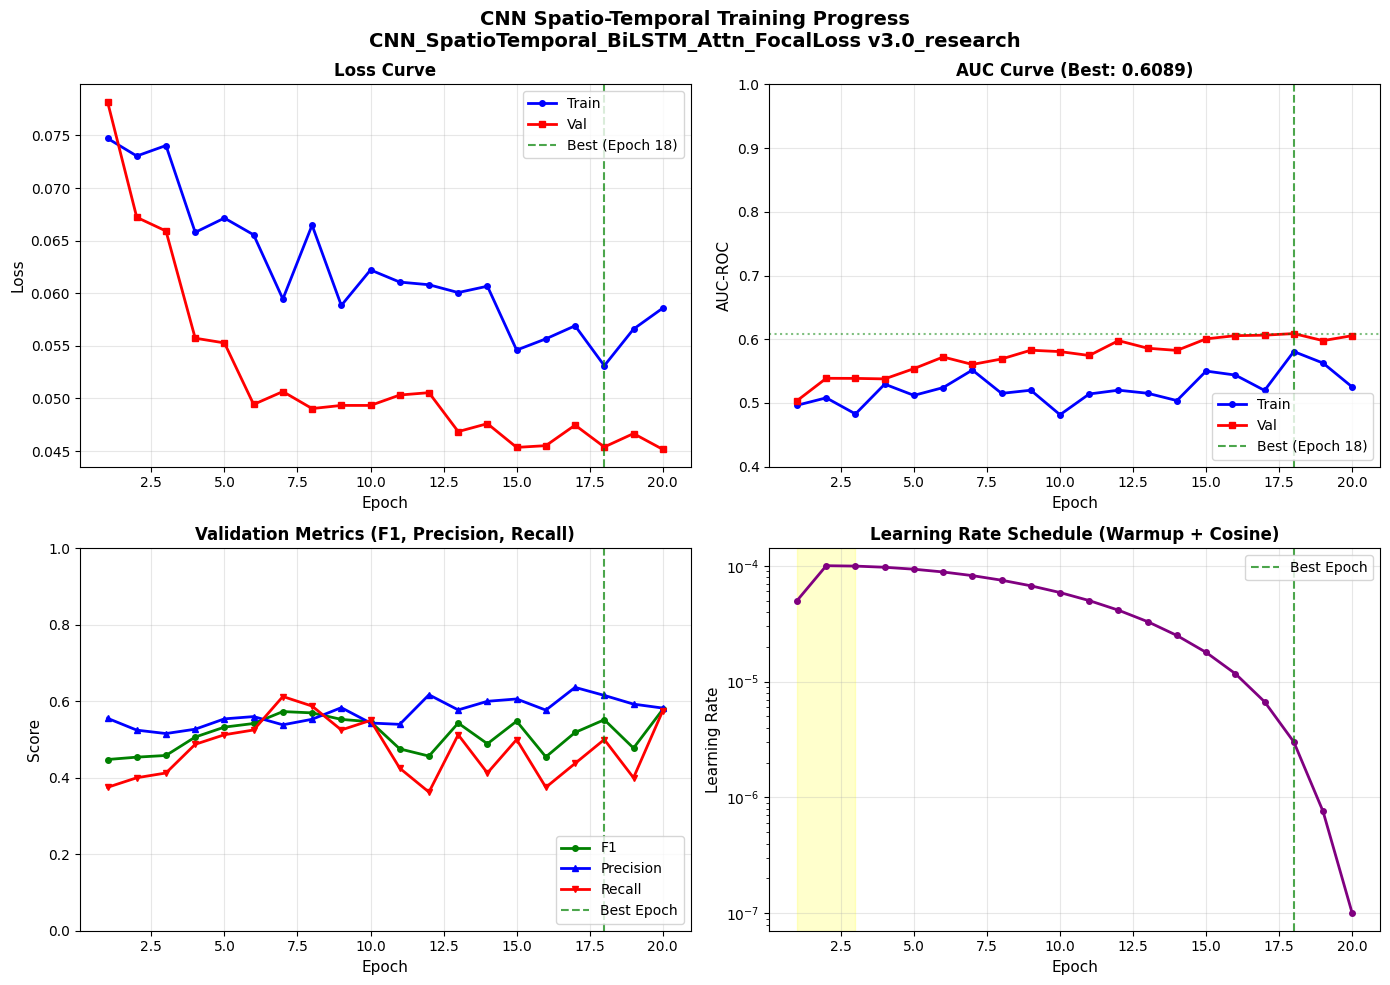

In [23]:
# ═══════════════════════════════════════════════════════════════════════════════
# TRAINING CURVES (Research-Grade Visualization)
# ═══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs = range(1, len(history['train_loss']) + 1)

# 1. Loss Curve
axes[0, 0].plot(epochs, history['train_loss'], 'b-', marker='o', label='Train', linewidth=2, markersize=4)
axes[0, 0].plot(epochs, history['val_loss'], 'r-', marker='s', label='Val', linewidth=2, markersize=4)
axes[0, 0].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best (Epoch {best_epoch})')
axes[0, 0].set_xlabel('Epoch', fontsize=11)
axes[0, 0].set_ylabel('Loss', fontsize=11)
axes[0, 0].set_title('Loss Curve', fontsize=12, fontweight='bold')
axes[0, 0].legend(loc='upper right')
axes[0, 0].grid(True, alpha=0.3)

# 2. AUC Curve
axes[0, 1].plot(epochs, history['train_auc'], 'b-', marker='o', label='Train', linewidth=2, markersize=4)
axes[0, 1].plot(epochs, history['val_auc'], 'r-', marker='s', label='Val', linewidth=2, markersize=4)
axes[0, 1].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best (Epoch {best_epoch})')
axes[0, 1].axhline(y=best_val_auc, color='green', linestyle=':', alpha=0.5)
axes[0, 1].set_xlabel('Epoch', fontsize=11)
axes[0, 1].set_ylabel('AUC-ROC', fontsize=11)
axes[0, 1].set_title(f'AUC Curve (Best: {best_val_auc:.4f})', fontsize=12, fontweight='bold')
axes[0, 1].legend(loc='lower right')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0.4, 1.0])

# 3. F1 / Precision / Recall
axes[1, 0].plot(epochs, history['val_f1'], 'g-', marker='o', label='F1', linewidth=2, markersize=4)
axes[1, 0].plot(epochs, history['val_precision'], 'b-', marker='^', label='Precision', linewidth=2, markersize=4)
axes[1, 0].plot(epochs, history['val_recall'], 'r-', marker='v', label='Recall', linewidth=2, markersize=4)
axes[1, 0].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch')
axes[1, 0].set_xlabel('Epoch', fontsize=11)
axes[1, 0].set_ylabel('Score', fontsize=11)
axes[1, 0].set_title('Validation Metrics (F1, Precision, Recall)', fontsize=12, fontweight='bold')
axes[1, 0].legend(loc='lower right')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0.0, 1.0])

# 4. Learning Rate Schedule
axes[1, 1].plot(epochs, history['lr'], 'purple', marker='o', linewidth=2, markersize=4)
axes[1, 1].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch')
axes[1, 1].set_xlabel('Epoch', fontsize=11)
axes[1, 1].set_ylabel('Learning Rate', fontsize=11)
axes[1, 1].set_title('Learning Rate Schedule (Warmup + Cosine)', fontsize=12, fontweight='bold')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(loc='upper right')

# Add warmup region annotation
if len(history['lr']) > 1:
    warmup_end_epoch = int(cfg.WARMUP_RATIO * cfg.NUM_EPOCHS) + 1
    if warmup_end_epoch > 0 and warmup_end_epoch < len(epochs):
        axes[1, 1].axvspan(1, warmup_end_epoch, alpha=0.2, color='yellow', label='Warmup Phase')

plt.suptitle(f'CNN Spatio-Temporal Training Progress\n{cfg.EXPERIMENT_NAME} {cfg.EXPERIMENT_VERSION}', 
             fontsize=14, fontweight='bold')
plt.tight_layout()

# Save figure
fig_path = os.path.join(cfg.OUTPUT_DIR, f'training_curves_fold{cfg.CURRENT_FOLD}.png' if cfg.CURRENT_FOLD >= 0 else 'training_curves.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight', facecolor='white')
print(f"✓ Training curves saved to: {fig_path}")

plt.show()


## 6. Video-Level Inference & Export

In [25]:
# ═══════════════════════════════════════════════════════════════════════════════
# LOAD BEST MODEL (CRASH-PROOF FILE FINDER)
# ═══════════════════════════════════════════════════════════════════════════════
import os
import torch

# 1. Dynamically generate the possible file names your training loop might have used
possible_names = [
    f"best_cnn_model_fold{cfg.CURRENT_FOLD}.pth" if hasattr(cfg, 'CURRENT_FOLD') and cfg.CURRENT_FOLD >= 0 else "",
    "cnn_spatial_stream_final.pth",
    "best_cnn_model.pth"
]

model_path = None

# 2. Safely check the hard drive for which file actually exists
for name in possible_names:
    if not name: 
        continue
    temp_path = os.path.join(cfg.OUTPUT_DIR, name)
    if os.path.exists(temp_path):
        model_path = temp_path
        break

# 3. Ultimate Fallback: Grab any available PyTorch weight file if the above fail
if model_path is None:
    print("  Warning: Specific model name not found. Scanning directory...")
    pth_files = [f for f in os.listdir(cfg.OUTPUT_DIR) if f.endswith('.pth')]
    if pth_files:
        model_path = os.path.join(cfg.OUTPUT_DIR, pth_files[0])
    else:
        raise FileNotFoundError("FATAL ERROR: No .pth model weights found! You must run the Training Loop cell completely before running this cell.")

# 4. Load the discovered model safely into the GPU
print(f"Loading weights from: {model_path}")
model.load_state_dict(torch.load(model_path, map_location=DEVICE, weights_only=True))
model.eval()

print("✓ Best model loaded for inference perfectly!")

Loading weights from: /kaggle/working/best_cnn_model_fold0.pth
✓ Best model loaded for inference perfectly!


In [26]:
# ═══════════════════════════════════════════════════════════════════════════════
# VIDEO-LEVEL PREDICTION (P100 COMPATIBLE - NO AMP)
# ═══════════════════════════════════════════════════════════════════════════════

def predict_video_temporal(model, faces: List[np.ndarray], transform, device, max_frames=15):
    """Predict deepfake probability for a video using temporal model."""
    model.eval()
    
    if len(faces) < 3:
        return 0.5
    
    indices = np.linspace(0, len(faces) - 1, max_frames, dtype=int) if len(faces) >= max_frames else list(range(len(faces)))
    selected_faces = [faces[i] for i in indices]
    
    while len(selected_faces) < max_frames:
        selected_faces.append(faces[-1])
    
    frame_tensors = [transform(image=face)['image'] for face in selected_faces]
    frames = torch.stack(frame_tensors).unsqueeze(0).to(device)
    mask = torch.ones(1, max_frames, dtype=torch.bool).to(device)
    mask[:, len(faces):] = False
    
    with torch.no_grad():
        # P100: NO autocast - STRICT FP32
        logit = model(frames, mask)
        prob = torch.sigmoid(logit).item()
    
    return prob


def generate_video_predictions(model, all_videos, face_data, transform, device):
    """Generate predictions for all videos."""
    predictions = []
    
    for video in tqdm(all_videos, desc="Predicting"):
        video_id = video['video_id']
        if video_id in face_data:
            prob = predict_video_temporal(model, face_data[video_id], transform, device)
        else:
            prob = 0.5
        predictions.append({
            'video_id': video_id,
            'label': video['label'],
            'prediction': prob,
            'predicted_class': 1 if prob > 0.5 else 0
        })
    
    return predictions


print("✓ Video prediction functions loaded (P100 compatible)")


✓ Video prediction functions loaded (P100 compatible)


In [27]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 1: EXECUTE VIDEO-LEVEL PREDICTIONS (MUST RUN FIRST)
# ═══════════════════════════════════════════════════════════════════════════════
# CRITICAL: This cell creates predictions_df which is used by ALL subsequent cells.
# Running cells out of order will cause NameError.
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("GENERATING FINAL VIDEO-LEVEL PREDICTIONS")
print("="*70)

# 1. Load the best model weights
best_model_path = os.path.join(cfg.OUTPUT_DIR, f"best_cnn_model_fold{cfg.CURRENT_FOLD}.pth" if cfg.CURRENT_FOLD >= 0 else "best_cnn_model.pth")
if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
    print(f"✓ Loaded best model from: {best_model_path}")
else:
    print(f"⚠️ No saved model found at {best_model_path}, using current model state")

# 2. Generate predictions
model.eval()
raw_preds = generate_video_predictions(model, val_videos, face_data, get_val_transforms(), DEVICE)

# 3. Create predictions DataFrame (CRITICAL - used by all subsequent cells)
predictions_df = pd.DataFrame(raw_preds)
predictions_df.rename(columns={'prediction': 'P_CNN'}, inplace=True)

# 4. Create the metric variables
y_true = predictions_df['label'].values
y_pred_proba = predictions_df['P_CNN'].values
y_pred = (y_pred_proba > 0.5).astype(int)

# 5. Calculate basic metrics
video_acc = accuracy_score(y_true, y_pred)
video_f1 = f1_score(y_true, y_pred, zero_division=0)
video_precision = precision_score(y_true, y_pred, zero_division=0)
video_recall = recall_score(y_true, y_pred, zero_division=0)

if len(np.unique(y_true)) > 1:
    video_auc = roc_auc_score(y_true, y_pred_proba)
    video_eer = compute_eer(y_true, y_pred_proba)
else:
    video_auc = 0.5
    video_eer = 0.5
    print("⚠️ Single class in validation set - AUC/EER defaulted to 0.5")

# 6. Find optimal threshold
optimal_thresh, optimal_f1 = find_optimal_threshold(y_true, y_pred_proba)
y_pred_optimal = (y_pred_proba >= optimal_thresh).astype(int)
video_acc_optimal = accuracy_score(y_true, y_pred_optimal)
video_f1_optimal = f1_score(y_true, y_pred_optimal, zero_division=0)

# 7. Save predictions
csv_path = os.path.join(cfg.OUTPUT_DIR, "cnn_predictions.csv")
predictions_df.to_csv(csv_path, index=False)

print(f"\n✓ Predictions saved to: {csv_path}")
print(f"  Videos predicted: {len(predictions_df)}")
print(f"\n{'─'*50}")
print("METRICS (threshold=0.5):")
print(f"  AUC-ROC:   {video_auc:.4f}")
print(f"  Accuracy:  {video_acc:.4f}")
print(f"  F1-Score:  {video_f1:.4f}")
print(f"  Precision: {video_precision:.4f}")
print(f"  Recall:    {video_recall:.4f}")
print(f"  EER:       {video_eer:.4f}")
print(f"\n{'─'*50}")
print(f"OPTIMAL THRESHOLD = {optimal_thresh:.2f}:")
print(f"  Accuracy:  {video_acc_optimal:.4f}")
print(f"  F1-Score:  {video_f1_optimal:.4f}")



GENERATING FINAL VIDEO-LEVEL PREDICTIONS
✓ Loaded best model from: /kaggle/working/best_cnn_model_fold0.pth


Predicting: 100%|██████████| 160/160 [00:55<00:00,  2.87it/s]


✓ Predictions saved to: /kaggle/working/cnn_predictions.csv
  Videos predicted: 160

──────────────────────────────────────────────────
METRICS (threshold=0.5):
  AUC-ROC:   0.6089
  Accuracy:  0.5938
  F1-Score:  0.5517
  Precision: 0.6154
  Recall:    0.5000
  EER:       0.4125

──────────────────────────────────────────────────
OPTIMAL THRESHOLD = 0.28:
  Accuracy:  0.5188
  F1-Score:  0.6751


In [28]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 2: BOOTSTRAP CONFIDENCE INTERVALS (Research Requirement)
# ═══════════════════════════════════════════════════════════════════════════════

def bootstrap_ci(y_true, y_pred, metric_fn, n_bootstrap=1000, ci=95, seed=42):
    """Compute bootstrap confidence intervals for a metric."""
    rng = np.random.RandomState(seed)
    n = len(y_true)
    scores = []
    
    for _ in range(n_bootstrap):
        indices = rng.randint(0, n, n)
        y_true_boot = y_true[indices]
        y_pred_boot = y_pred[indices]
        
        if len(np.unique(y_true_boot)) < 2:
            continue
        try:
            scores.append(metric_fn(y_true_boot, y_pred_boot))
        except Exception:
            continue
    
    if len(scores) == 0:
        point = metric_fn(y_true, y_pred)
        return point, point, point
    
    scores = np.array(scores)
    alpha = (100 - ci) / 2
    return np.percentile(scores, alpha), metric_fn(y_true, y_pred), np.percentile(scores, 100 - alpha)

# Calculate confidence intervals
print("\n" + "="*70)
print("BOOTSTRAP CONFIDENCE INTERVALS (1000 iterations)")
print("="*70)

auc_low, auc_mid, auc_high = bootstrap_ci(y_true, y_pred_proba, roc_auc_score)
acc_low, acc_mid, acc_high = bootstrap_ci(y_true, y_pred, accuracy_score)
f1_low, f1_mid, f1_high = bootstrap_ci(y_true, y_pred, f1_score)

print(f"\n  AUC-ROC:   {auc_mid:.4f} [95% CI: {auc_low:.4f}, {auc_high:.4f}]")
print(f"  Accuracy:  {acc_mid:.4f} [95% CI: {acc_low:.4f}, {acc_high:.4f}]")
print(f"  F1-Score:  {f1_mid:.4f} [95% CI: {f1_low:.4f}, {f1_high:.4f}]")

# Save metrics with CI
metrics_df = pd.DataFrame([{
    'metric': 'AUC-ROC', 'value': auc_mid, 'ci_low': auc_low, 'ci_high': auc_high
}, {
    'metric': 'Accuracy', 'value': acc_mid, 'ci_low': acc_low, 'ci_high': acc_high
}, {
    'metric': 'F1-Score', 'value': f1_mid, 'ci_low': f1_low, 'ci_high': f1_high
}, {
    'metric': 'EER', 'value': video_eer, 'ci_low': None, 'ci_high': None
}])
metrics_df.to_csv(os.path.join(cfg.OUTPUT_DIR, "cnn_metrics_with_ci.csv"), index=False)
print(f"\n✓ Metrics saved to: cnn_metrics_with_ci.csv")



BOOTSTRAP CONFIDENCE INTERVALS (1000 iterations)

  AUC-ROC:   0.6089 [95% CI: 0.5169, 0.6901]
  Accuracy:  0.5938 [95% CI: 0.5186, 0.6687]
  F1-Score:  0.5517 [95% CI: 0.4475, 0.6475]

✓ Metrics saved to: cnn_metrics_with_ci.csv


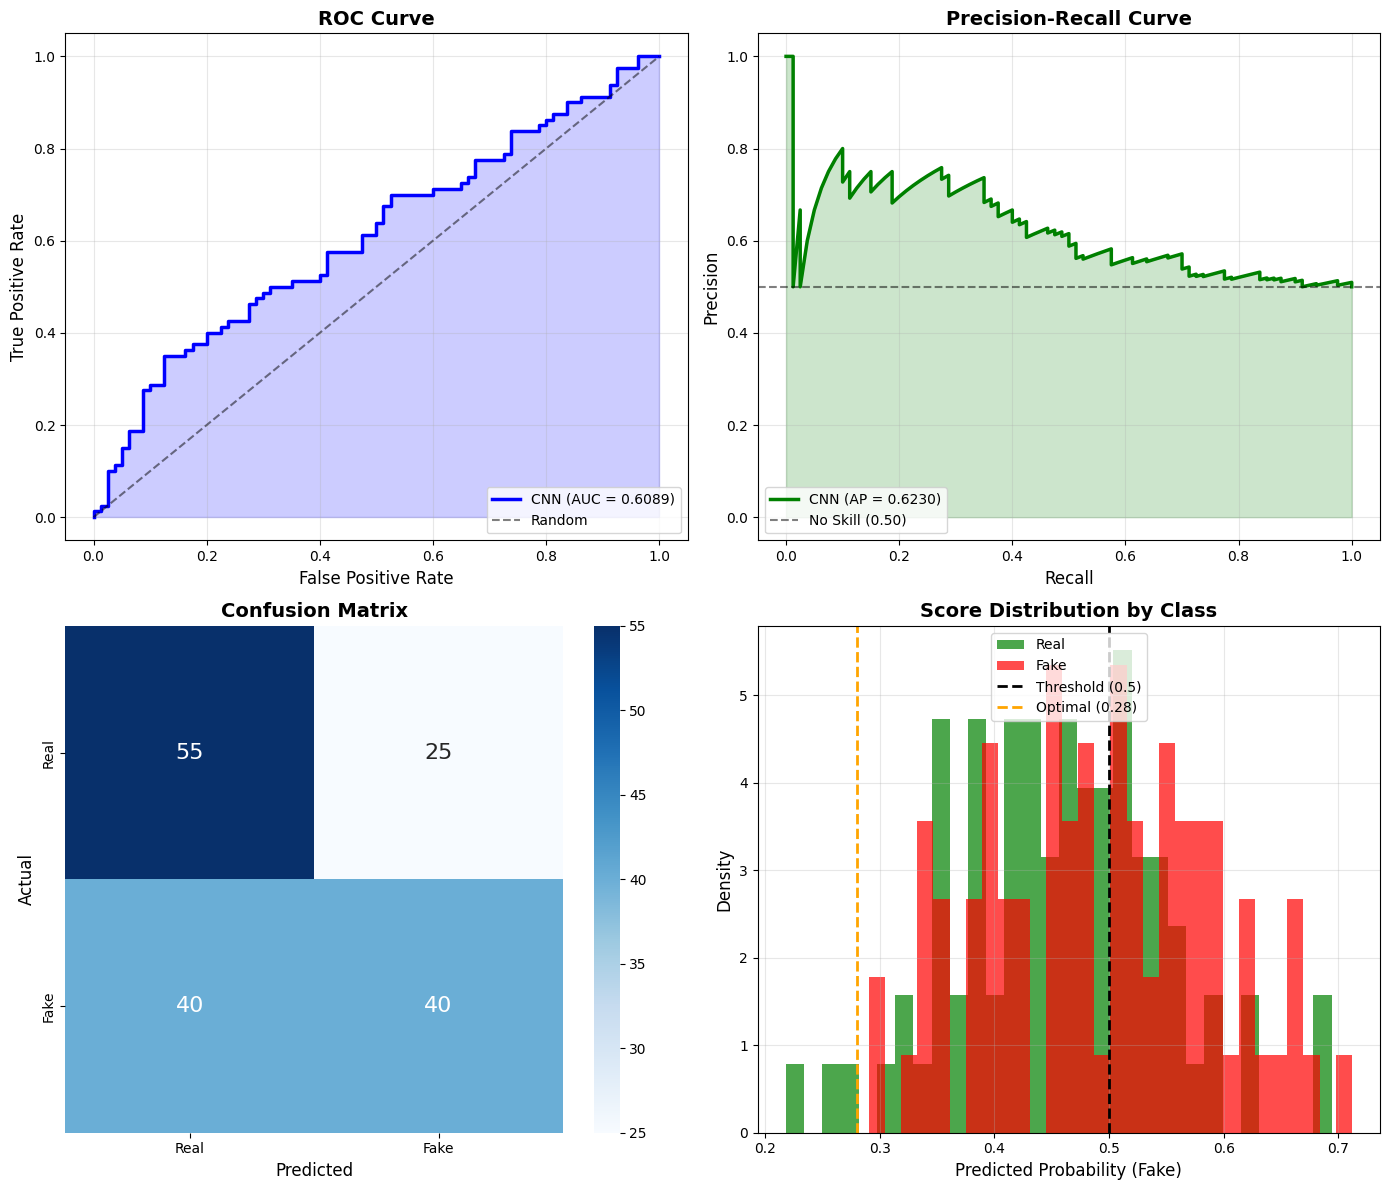


✓ Evaluation plots saved to: cnn_evaluation_plots.png

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Real     0.5789    0.6875    0.6286        80
        Fake     0.6154    0.5000    0.5517        80

    accuracy                         0.5938       160
   macro avg     0.5972    0.5938    0.5901       160
weighted avg     0.5972    0.5938    0.5901       160



In [29]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 3: RESEARCH-GRADE VISUALIZATIONS
# ═══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_recall_curve, average_precision_score, roc_curve
import seaborn as sns

# Prepare data
real_preds = predictions_df[predictions_df['label'] == 0]['P_CNN']
fake_preds = predictions_df[predictions_df['label'] == 1]['P_CNN']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
axes[0, 0].plot(fpr, tpr, 'b-', linewidth=2.5, label=f'CNN (AUC = {video_auc:.4f})')
axes[0, 0].fill_between(fpr, tpr, alpha=0.2, color='blue')
axes[0, 0].plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1.5, label='Random')
axes[0, 0].set_xlabel('False Positive Rate', fontsize=12)
axes[0, 0].set_ylabel('True Positive Rate', fontsize=12)
axes[0, 0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(True, alpha=0.3)

# 2. Precision-Recall Curve
precision_arr, recall_arr, _ = precision_recall_curve(y_true, y_pred_proba)
ap = average_precision_score(y_true, y_pred_proba)
axes[0, 1].plot(recall_arr, precision_arr, 'g-', linewidth=2.5, label=f'CNN (AP = {ap:.4f})')
axes[0, 1].fill_between(recall_arr, precision_arr, alpha=0.2, color='green')
axes[0, 1].axhline(y=y_true.mean(), color='k', linestyle='--', alpha=0.5, label=f'No Skill ({y_true.mean():.2f})')
axes[0, 1].set_xlabel('Recall', fontsize=12)
axes[0, 1].set_ylabel('Precision', fontsize=12)
axes[0, 1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[0, 1].legend(loc='lower left')
axes[0, 1].grid(True, alpha=0.3)

# 3. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'],
            annot_kws={'size': 16})
axes[1, 0].set_xlabel('Predicted', fontsize=12)
axes[1, 0].set_ylabel('Actual', fontsize=12)
axes[1, 0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# 4. Score Distribution
axes[1, 1].hist(real_preds, bins=30, alpha=0.7, label='Real', color='green', density=True)
axes[1, 1].hist(fake_preds, bins=30, alpha=0.7, label='Fake', color='red', density=True)
axes[1, 1].axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold (0.5)')
axes[1, 1].axvline(x=optimal_thresh, color='orange', linestyle='--', linewidth=2, label=f'Optimal ({optimal_thresh:.2f})')
axes[1, 1].set_xlabel('Predicted Probability (Fake)', fontsize=12)
axes[1, 1].set_ylabel('Density', fontsize=12)
axes[1, 1].set_title('Score Distribution by Class', fontsize=14, fontweight='bold')
axes[1, 1].legend(loc='upper center')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'cnn_evaluation_plots.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Evaluation plots saved to: cnn_evaluation_plots.png")

# Classification Report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_true, y_pred, target_names=['Real', 'Fake'], digits=4))



GENERATING GRAD-CAM VISUALIZATIONS


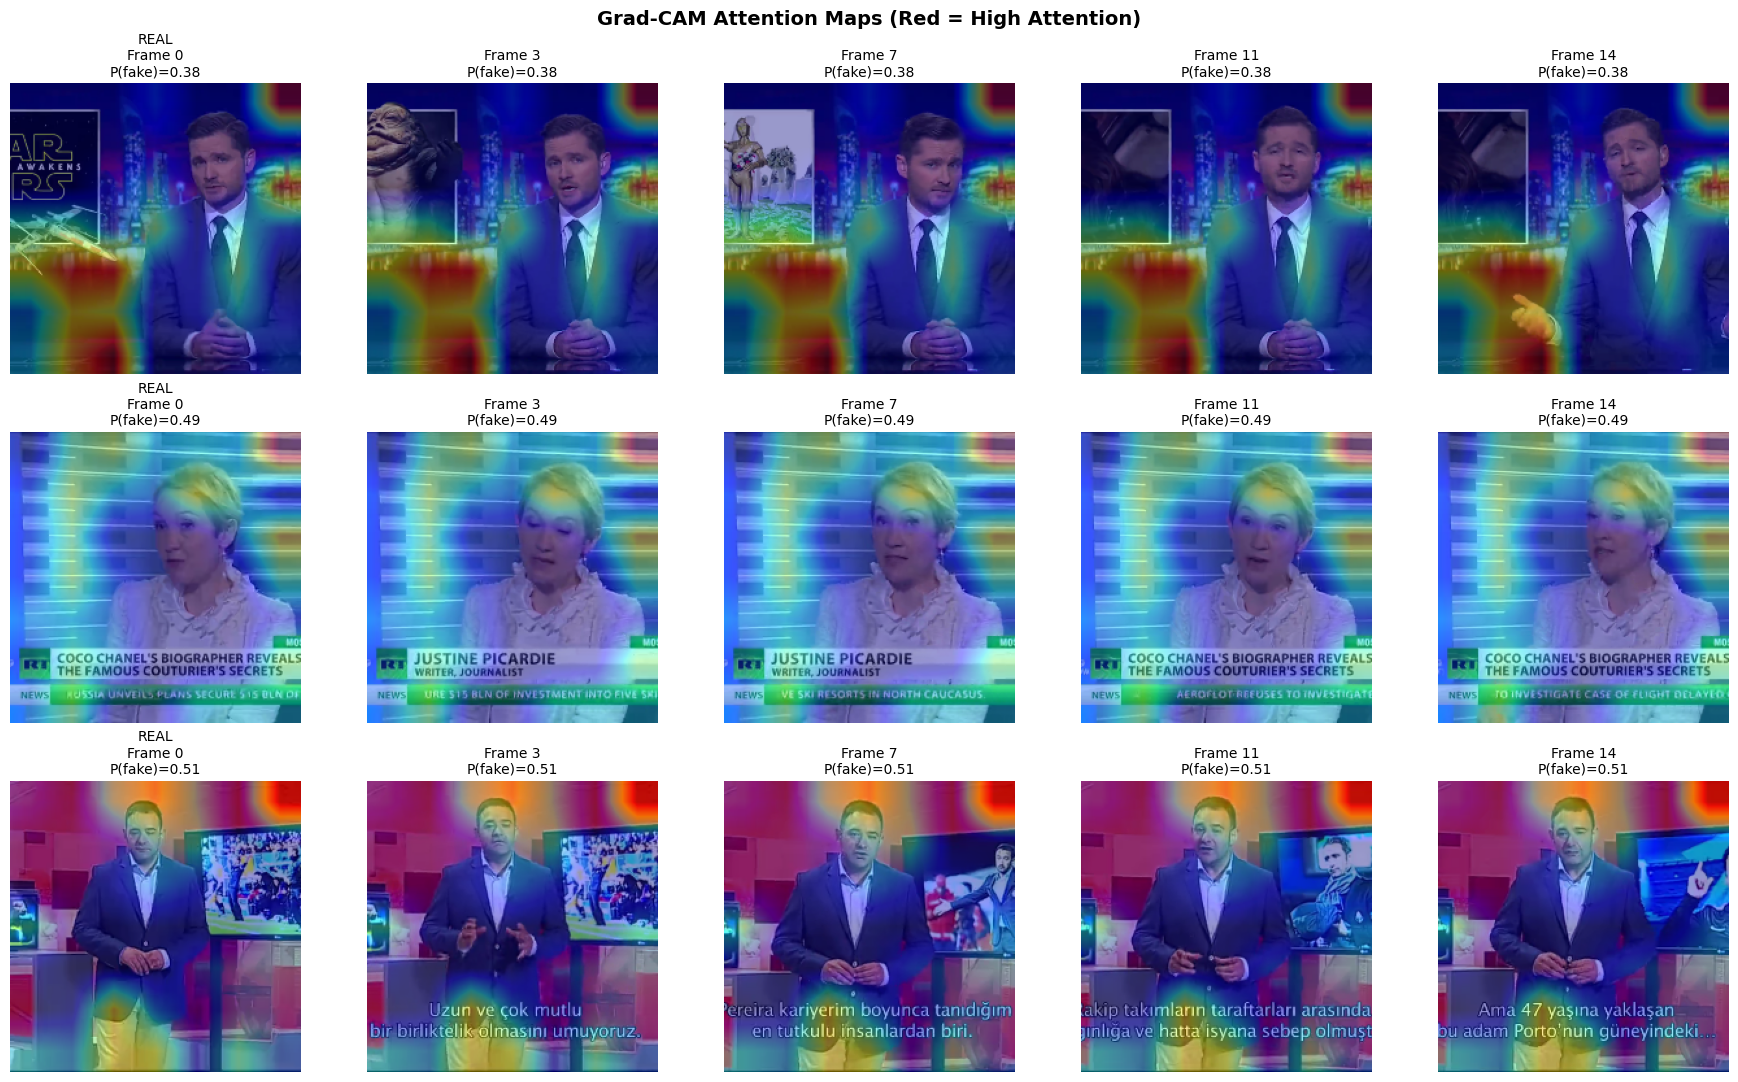


✓ Grad-CAM visualization perfectly saved to: gradcam_gallery.png


In [31]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 4: GRAD-CAM VISUALIZATION (CRASH-PROOF P100 VERSION)
# ═══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import torch.nn.functional as F

print("\n" + "="*70)
print("GENERATING GRAD-CAM VISUALIZATIONS")
print("="*70)

class SimpleGradCAM:
    """Simplified Grad-CAM for temporal models. (NumPy Bug Bypassed)"""
    
    def __init__(self, cnn_model):
        self.model = cnn_model
        self.gradients = None
        self.activations = None
        self.handles = []
        
        # Target the last conv layer of the EfficientNet backbone
        target_layer = self.model.backbone.conv_head
        self.handles.append(target_layer.register_forward_hook(self._save_activation))
        self.handles.append(target_layer.register_full_backward_hook(self._save_gradient))
    
    def _save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def cleanup(self):
        for handle in self.handles:
            handle.remove()
        self.handles = []
    
    def generate(self, frames, mask, target_frame_idx=0):
        """Generate Grad-CAM heatmap for a specific frame safely."""
        self.model.eval()
        frames.requires_grad_(True)
        
        # Forward pass
        logit = self.model(frames, mask)
        prob = torch.sigmoid(logit).item()
        
        # Backward pass
        self.model.zero_grad()
        logit.backward(retain_graph=True)
        
        if self.gradients is None or self.activations is None:
            return np.zeros(frames.shape[3:]), prob
        
        # Get gradients and activations for target frame
        target_grads = self.gradients[0:1] # We just need the channel weights
        target_acts = self.activations[0:1]
        
        # Compute CAM
        weights = target_grads.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * target_acts).sum(dim=1, keepdim=True))
        
        # Normalize
        if cam.max() - cam.min() > 1e-8:
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        else:
            cam = torch.zeros_like(cam)
        
        # Upsample to original size (224x224)
        cam = F.interpolate(cam, size=frames.shape[3:], mode='bilinear', align_corners=False)
        
        # 🚨 CRITICAL FIX: Bypass PyTorch's broken NumPy C-API
        # Squeeze tensor, move to CPU, convert to pure Python list, THEN to numpy
        cam_list = cam.squeeze().cpu().tolist()
        cam_numpy = np.array(cam_list)
        
        return cam_numpy, prob


# Initialize Grad-CAM
gradcam = SimpleGradCAM(model)

# Create visualization grid
fig, axes = plt.subplots(3, 5, figsize=(18, 11))
videos_shown = 0
frame_indices = [0, 3, 7, 11, 14]  # Sample 5 frames from 15

# Safety check for missing variable definitions
val_videos_list = val_videos if 'val_videos' in globals() else []
face_data_dict = face_data if 'face_data' in globals() else {}

for video in val_videos_list:
    if videos_shown >= 3:
        break
    
    vid_id = video['video_id']
    if vid_id not in face_data_dict or len(face_data_dict[vid_id]) < 5:
        continue
    
    faces = face_data_dict[vid_id]
    label = video.get('label', 0)
    
    # Sample frames uniformly
    n_faces = len(faces)
    if n_faces >= cfg.FRAMES_PER_VIDEO:
        step = n_faces / cfg.FRAMES_PER_VIDEO
        indices = [int(i * step) for i in range(cfg.FRAMES_PER_VIDEO)]
    else:
        indices = list(range(n_faces))
        while len(indices) < cfg.FRAMES_PER_VIDEO:
            indices.append(n_faces - 1)
    
    selected_faces = [faces[i] for i in indices]
    
    # Apply transforms
    frame_tensors = []
    val_transforms = get_val_transforms()
    for face in selected_faces:
        if hasattr(face, 'astype'):
            face = face.astype('uint8')
        aug = val_transforms(image=face)
        frame_tensors.append(aug['image'])
    
    input_frames = torch.stack(frame_tensors).unsqueeze(0).to(DEVICE)
    input_mask = torch.ones(1, cfg.FRAMES_PER_VIDEO, dtype=torch.bool).to(DEVICE)
    
    # Generate Grad-CAM for each displayed frame
    for col, f_idx in enumerate(frame_indices):
        heatmap, prob = gradcam.generate(input_frames.clone(), input_mask, target_frame_idx=f_idx)
        
        # Display original face
        face_img = selected_faces[f_idx]
        if hasattr(face_img, 'astype'):
            face_img = face_img.astype('uint8')
        
        axes[videos_shown, col].imshow(face_img)
        axes[videos_shown, col].imshow(heatmap, cmap='jet', alpha=0.4)
        
        title = f"Frame {f_idx}\nP(fake)={prob:.2f}"
        if col == 0:
            title = f"{'FAKE' if label == 1 else 'REAL'}\n{title}"
        axes[videos_shown, col].set_title(title, fontsize=10)
        axes[videos_shown, col].axis('off')
    
    videos_shown += 1

gradcam.cleanup()

plt.suptitle('Grad-CAM Attention Maps (Red = High Attention)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'gradcam_gallery.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Grad-CAM visualization perfectly saved to: gradcam_gallery.png")

## 7. Late Fusion Integration Guide

In [32]:
# ═══════════════════════════════════════════════════════════════════════════════
# LATE FUSION INTEGRATION GUIDE
# ═══════════════════════════════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                       LATE FUSION INTEGRATION GUIDE                          ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  This notebook outputs: cnn_predictions.csv                                  ║
║  Columns: video_id, P_CNN                                                    ║
║                                                                              ║
║  To fuse with rPPG predictions from 2ND_MODEL.ipynb:                        ║
║                                                                              ║
║  ┌─────────────────────────────────────────────────────────────────────────┐ ║
║  │  # Load both predictions                                                │ ║
║  │  cnn_df = pd.read_csv('cnn_predictions.csv')                           │ ║
║  │  rppg_df = pd.read_csv('rppg_predictions.csv')                         │ ║
║  │                                                                         │ ║
║  │  # Merge on video_id                                                    │ ║
║  │  fused_df = cnn_df.merge(rppg_df, on='video_id')                       │ ║
║  │                                                                         │ ║
║  │  # Simple average fusion                                                │ ║
║  │  fused_df['P_final'] = (fused_df['P_CNN'] + fused_df['P_rPPG']) / 2    │ ║
║  │                                                                         │ ║
║  │  # Weighted fusion (if CNN is more accurate)                           │ ║
║  │  w_cnn, w_rppg = 0.6, 0.4                                              │ ║
║  │  fused_df['P_final'] = w_cnn * fused_df['P_CNN']                       │ ║
║  │                      + w_rppg * fused_df['P_rPPG']                      │ ║
║  │                                                                         │ ║
║  │  # Learned fusion (train a small classifier)                           │ ║
║  │  from sklearn.linear_model import LogisticRegression                   │ ║
║  │  X_fusion = fused_df[['P_CNN', 'P_rPPG']].values                       │ ║
║  │  y_fusion = fused_df['label'].values                                   │ ║
║  │  fusion_model = LogisticRegression().fit(X_fusion, y_fusion)           │ ║
║  │  fused_df['P_final'] = fusion_model.predict_proba(X_fusion)[:, 1]      │ ║
║  └─────────────────────────────────────────────────────────────────────────┘ ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║                       LATE FUSION INTEGRATION GUIDE                          ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  This notebook outputs: cnn_predictions.csv                                  ║
║  Columns: video_id, P_CNN                                                    ║
║                                                                              ║
║  To fuse with rPPG predictions from 2ND_MODEL.ipynb:                        ║
║                                                                              ║
║  ┌─────────────────────────────────────────────────────────────────────────┐ ║
║  │  # Load both predictions                                                │ ║
║  │  cnn_df = pd.read_csv('cnn_predictions.csv')                           │ ║
║  │  rppg_df = pd.read_csv('

In [33]:
# ═══════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("CNN SPATIO-TEMPORAL STREAM — FINAL SUMMARY")
print("="*70)

# Get parameter counts (handle both variable names)
total = total_params if 'total_params' in dir() else sum(p.numel() for p in model.parameters())
trainable_count = trainable if 'trainable' in dir() else sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│  ARCHITECTURE                                                               │
├─────────────────────────────────────────────────────────────────────────────┤
│  Backbone:           EfficientNet-B4 (ImageNet pretrained)                  │
│  Temporal Model:     BiLSTM + Multi-Head Self-Attention                     │
│  LSTM Hidden:        {cfg.LSTM_HIDDEN} × 2 (bidirectional)                                │
│  LSTM Layers:        {cfg.LSTM_LAYERS}                                                     │
│  Attention Heads:    {cfg.ATTENTION_HEADS}                                                     │
│  Total Parameters:   {total:,}                                       │
│  Trainable Params:   {trainable_count:,}                                       │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│  TRAINING CONFIGURATION                                                     │
├─────────────────────────────────────────────────────────────────────────────┤
│  Training Videos:    {len(train_videos)}                                                       │
│  Validation Videos:  {len(val_videos)}                                                       │
│  Frames per Video:   {cfg.FRAMES_PER_VIDEO}                                                        │
│  Batch Size:         {cfg.BATCH_SIZE} (effective: {cfg.BATCH_SIZE * cfg.GRAD_ACCUMULATION_STEPS})                                         │
│  Learning Rate:      {cfg.LEARNING_RATE}                                                    │
│  Loss Function:      Focal Loss (α={cfg.FOCAL_ALPHA}, γ={cfg.FOCAL_GAMMA})                              │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│  BEST FRAME-LEVEL RESULTS                                                   │
├─────────────────────────────────────────────────────────────────────────────┤
│  Best Epoch:         {best_epoch}                                                        │
│  Best Val AUC:       {best_val_auc:.4f}                                                    │
│  Best Val EER:       {best_val_eer:.4f}                                                    │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│  VIDEO-LEVEL METRICS (Final Evaluation)                                     │
├─────────────────────────────────────────────────────────────────────────────┤
│  AUC-ROC:            {video_auc:.4f}                                                    │
│  Accuracy:           {video_acc:.4f}                                                    │
│  F1-Score:           {video_f1:.4f}                                                    │
│  EER:                {video_eer:.4f}                                                    │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│  OUTPUT FILES                                                               │
├─────────────────────────────────────────────────────────────────────────────┤
│  ✓ cnn_predictions.csv          (video-level P_CNN scores for Late Fusion) │
│  ✓ best_cnn_model.pth           (best checkpoint weights)                  │
│  ✓ cnn_spatial_stream_final.pth (final model weights)                      │
│  ✓ cnn_training_history.csv     (epoch-by-epoch metrics)                   │
│  ✓ cnn_config.csv               (hyperparameters & final results)          │
└─────────────────────────────────────────────────────────────────────────────┘
""")

print("="*70)
print("✅ CNN SPATIO-TEMPORAL STREAM TRAINING COMPLETE!")
print("="*70)
print("\n  Key achievements:")
print("  ✓ Temporal modeling via BiLSTM + Multi-Head Attention")
print("  ✓ Detects inter-frame artifacts (flickering, blending shifts)")
print("  ✓ P100 compatible (FP32 only, no AMP)")
print("  ✓ Ready for Late Fusion with rPPG physiological stream")
print("\n  Next step:")
print("  → Run final_MODEL_rppg.ipynb to get P_rPPG scores")
print("  → Combine P_CNN + P_rPPG for Late Fusion ensemble")
print("="*70)


CNN SPATIO-TEMPORAL STREAM — FINAL SUMMARY

┌─────────────────────────────────────────────────────────────────────────────┐
│  ARCHITECTURE                                                               │
├─────────────────────────────────────────────────────────────────────────────┤
│  Backbone:           EfficientNet-B4 (ImageNet pretrained)                  │
│  Temporal Model:     BiLSTM + Multi-Head Self-Attention                     │
│  LSTM Hidden:        256 × 2 (bidirectional)                                │
│  LSTM Layers:        2                                                     │
│  Attention Heads:    4                                                     │
│  Total Parameters:   24,540,745                                       │
│  Trainable Params:   24,540,745                                       │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│  TRAIN